# Telco Customer Churn Prediction

![fmtrr.png](https://media.licdn.com/dms/image/D4D12AQHdV5ztbrMvPg/article-cover_image-shrink_600_2000/0/1692641513128?e=2147483647&v=beta&t=P7i36VFGS5YBmhsV2kILoBshaa-7SXYmWj8FnP5QJ5M)

In this notebook, we will develop a machine learning model that can predict customers who will leave the company.

Before modeling, we will perform exploratory data analysis and feature engineering for the dataset.

The dataset contains various columns related to customer information of a telecommunications company, including demographic information, subscribed services, contract details, charges, and whether the customer has left (whether they churned).

Descriptions of Variables

CustomerID: Client ID

Gender: Client gender

SeniorCitizen: Whether the customer is a senior citizen (1: Yes, 0: No)

Partner: Whether the customer has a partner (Yes, No)

Dependents: Whether the customer has dependents (Yes, No)

tenure: Number of months the customer has stayed with the company

PhoneService: Whether the customer has phone service (Yes or No)

MultipleLines: Whether the customer has multiple lines (Yes, No, No phone service)

InternetService: Whether the customer has internet service (Yes, No, No internet service)

OnlineSecurity: Whether the customer has online security (Yes, No, No internet service)

OnlineBackup: Whether the customer has online backup (Yes, No, No internet service)

DeviceProtection: Whether the customer has device protection (Yes, No, No internet service)

TechSupport: Whether the customer has tech support (Yes, No, No internet service)

StreamingTV: Whether the customer has TV streaming (Yes, No, No internet service)

StreamingMovies: Whether the customer has movie streaming (Yes, No, No internet service)

Contract: Customer's contract term (month-to-month, one year, two years)

PaperlessBilling: Whether the customer has paperless billing (Yes, No)

PaymentMethod: Customer payment method (Electronic check, mail, bank transfer (automatic), credit card (automatic))

MonthlyCharges: Monthly amount charged to the customer

TotalCharges: Total amount charged to the customer

Churn

# Importing necessary libraries and dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
# !pip install missingno
import missingno as msno
from datetime import date
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression


In [ ]:
df = pd.read_csv("../data/Telco_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Exploratory Data Analysis

In [3]:
def check_data(dataframe,head=5):
    print(20*"-" + "Information".center(20) + 20*"-")
    print(dataframe.info())
    print(20*"-" + "Data Shape".center(20) + 20*"-")
    print(dataframe.shape)
    print("\n" + 20*"-" + "The First 5 Data".center(20) + 20*"-")
    print(dataframe.head())
    print("\n" + 20 * "-" + "Missing Values".center(20) + 20 * "-")
    print(dataframe.isnull().sum())
    print("\n" + 40 * "-" + "Describe the Data".center(40) + 40 * "-")
    print(dataframe.describe([0.01, 0.05,0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T)

check_data(df)

--------------------    Information     --------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-n

There are no missing values in the dataset, which is a good thing. However, there are a few observations regarding the data types:

TotalCharges: This column is currently in object (string) format; this may indicate the presence of non-numeric characters. Ideally, this column should be in numeric format for analysis.

SeniorCitizen: It is an integer (int64), which is appropriate if it will be a binary indicator (0 or 1). However, if it is intended to represent an age category, we may need to reconsider this.

CustomerID: Although it is correct as an object type, this column may not be necessary for analysis unless we are tracking individual customers.

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for any new missing values in 'TotalCharges'
new_missing_values = df['TotalCharges'].isnull().sum()
new_missing_values

11

Converting the TotalCharges column into numeric format resulted in 11 new missing values. These are most likely cases where the original data contained non-numeric characters or empty strings that could not be converted into numbers.

We have several options to handle these missing values:

Remove the rows: If the dataset is large enough, removing 11 rows may not significantly affect the analysis.

Impute the values: We can fill these missing values with a statistic such as the mean or median, or with a value based on other columns (for example, using MonthlyCharges and tenure to estimate TotalCharges).

Investigate further: Before making a decision, we may want to check these specific rows to understand why the values are missing.

In [5]:
# Display the rows with missing values in 'TotalCharges'
missing_total_charges_rows = df[df['TotalCharges'].isnull()]
missing_total_charges_rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


When the rows with missing TotalCharges are examined, a pattern emerges: all of these customers have a tenure of 0. This indicates that these customers are new and have not yet been billed, which explains the absence of total charges.

In [6]:
df['TotalCharges'].fillna(0, inplace=True)


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Since CustomerID is likely a unique identifier for each customer and may not contribute to aggregate data analysis, we could either keep it for identification purposes or remove it if it's not needed for the analysis.

In [8]:
df.drop('customerID', axis=1, inplace=True)

# Display the first few rows of the dataset to confirm the drop
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


We will perform Exploratory Data Analysis (EDA) on the dataset. EDA is a very important step in data analysis because it helps us understand the distribution, trends, and relationships within the data. Here is a plan for our EDA:

Summary Statistics: We will start with basic summary statistics for the numerical columns.

Distribution of Variables: Analyze the distributions of key variables—both numerical (such as "tenure", "MonthlyCharges", "TotalCharges") and categorical (such as "gender", "InternetService", "Contract").

Correlation Analysis: Examine the correlations between numerical variables.

Churn Analysis: Since the target variable is "Churn", we will focus especially on how different variables relate to churn rates.

Visualizations: We will use various plots (such as histograms, bar charts, box plots, and scatter plots) to visualize the data and reveal patterns.

## Summary Statistics

In [9]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
 
   # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')
    return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 7043
Variables: 20
cat_cols: 17
num_cols: 3
cat_but_car: 0
num_but_cat: 1


## Numerical Variables

In [10]:
num_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [11]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


### Conclusions

Tenure: The average tenure is approximately 32 months and has a wide range (0 to 72 months), indicating a mix of new and long-term customers.

Monthly Charges: The average monthly charge is about USD 64.76, with charges ranging from USD 18.25 to USD 118.75.

Total Charges: Total charges vary greatly, with an average of around USD 2,279.73. The distribution is skewed, and the maximum charge is USD 8,684.80.

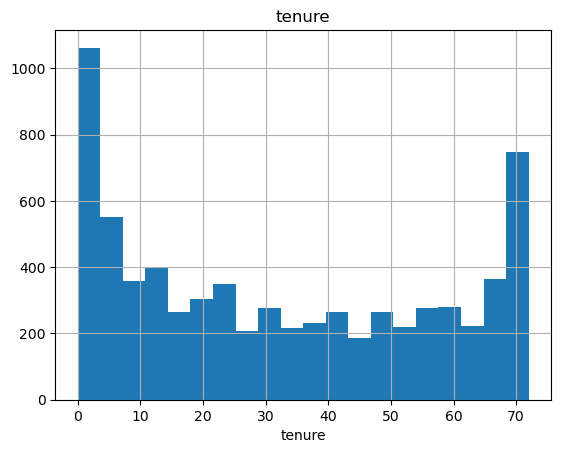

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
10%         2.000000
20%         6.000000
40%        20.000000
50%        29.000000
60%        40.000000
80%        60.000000
90%        69.000000
95%        72.000000
99%        72.000000
max        72.000000
Name: tenure, dtype: float64


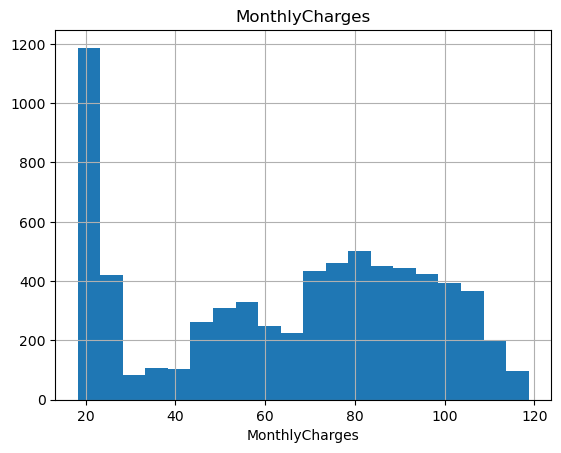

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
10%        20.050000
20%        25.050000
40%        58.830000
50%        70.350000
60%        79.100000
80%        94.250000
90%       102.600000
95%       107.400000
99%       114.729000
max       118.750000
Name: MonthlyCharges, dtype: float64


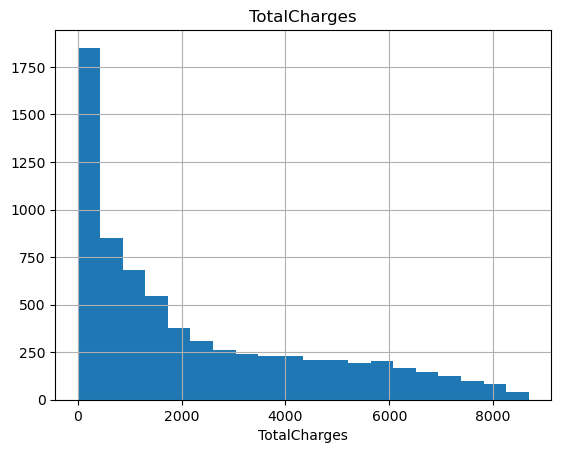

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
10%        83.470000
20%       265.320000
40%       939.780000
50%      1394.550000
60%      2043.710000
80%      4471.440000
90%      5973.690000
95%      6921.025000
99%      8039.256000
max      8684.800000
Name: TotalCharges, dtype: float64


In [12]:
def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.10, 0.20, 0.40, 0.50, 0.60, 0.80, 0.90, 0.95, 0.99]

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)
        print(dataframe[numerical_col].describe(quantiles).T)


for col in num_cols:
    num_summary(df, col, plot=True)

Comment

Tenure: The distribution shows two peaks, indicating a significant number of new customers (low tenure) and a significant number of long-term customers (high tenure). This bimodal distribution suggests two main customer groups in terms of how long they have stayed with the company.

Monthly Charges: The distribution is somewhat bimodal; one peak appears at the lower end (around USD 20) and another at the higher end (around USD 80–90). This indicates the presence of different customer groups based on the services they subscribe to—some prefer basic, lower-cost services, while others choose more expensive packages.

Total Charges: The distribution is right-skewed, which shows that many customers have relatively lower total charges; this is consistent with the fact that a large number of customers have low tenure.

## Categorical Variables

In [13]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']

In [14]:
df[cat_cols].describe(include=["object"])

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


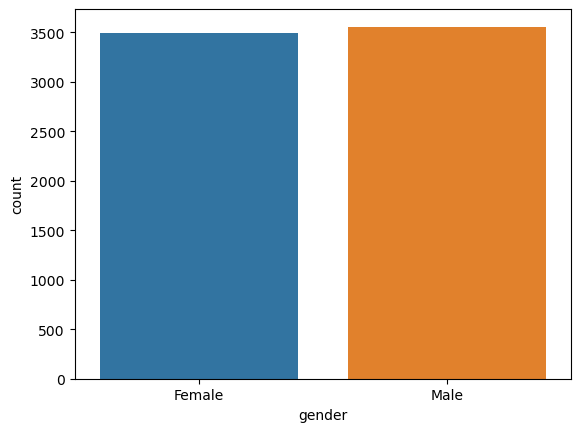

        gender     Ratio
Male      3555  50.47565
Female    3488  49.52435
##########################################


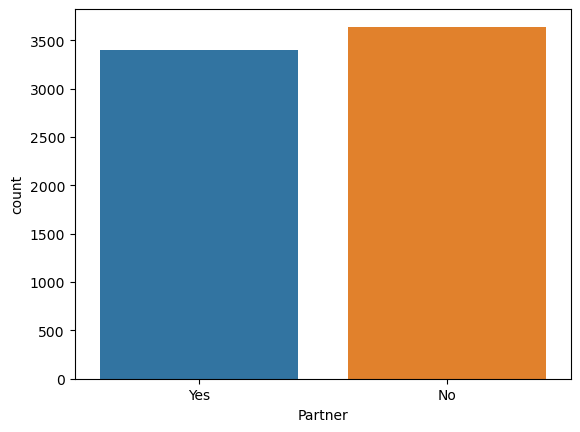

     Partner     Ratio
No      3641  51.69672
Yes     3402  48.30328
##########################################


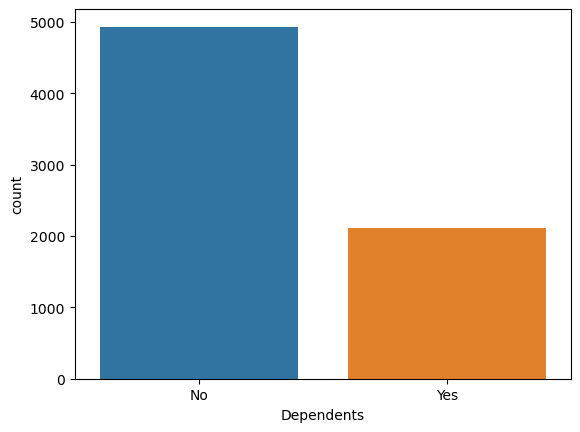

     Dependents      Ratio
No         4933  70.041176
Yes        2110  29.958824
##########################################


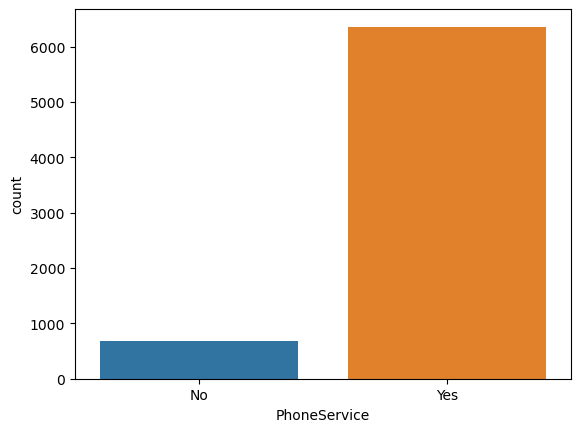

     PhoneService      Ratio
Yes          6361  90.316626
No            682   9.683374
##########################################


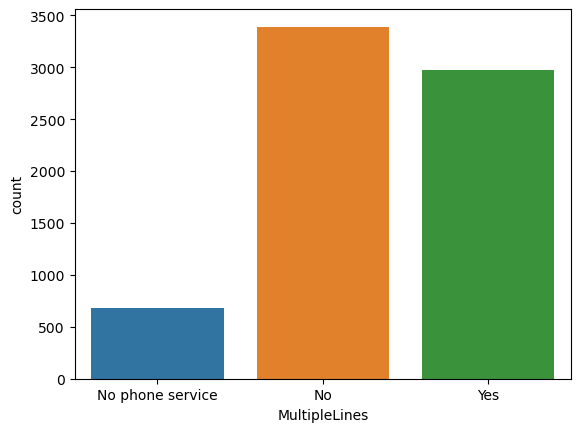

                  MultipleLines      Ratio
No                         3390  48.132898
Yes                        2971  42.183729
No phone service            682   9.683374
##########################################


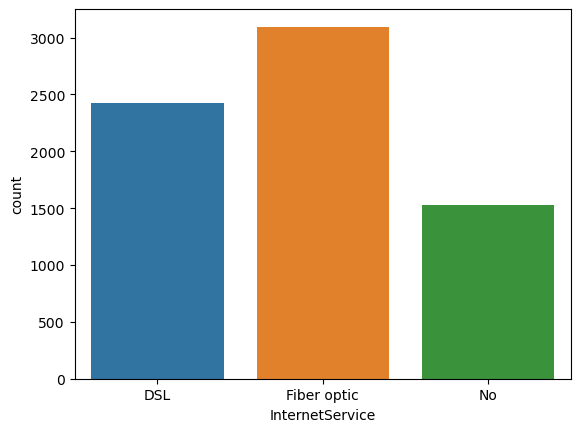

             InternetService      Ratio
Fiber optic             3096  43.958540
DSL                     2421  34.374556
No                      1526  21.666903
##########################################


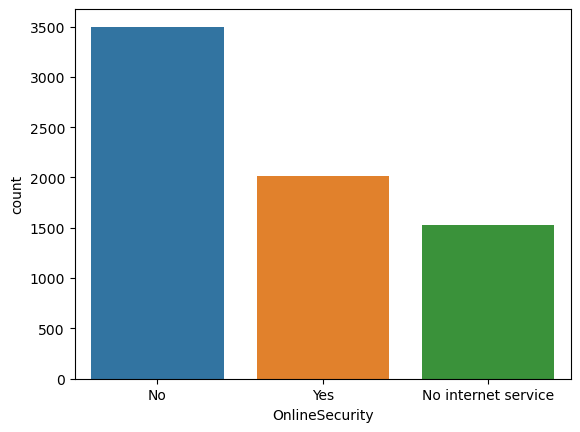

                     OnlineSecurity      Ratio
No                             3498  49.666335
Yes                            2019  28.666761
No internet service            1526  21.666903
##########################################


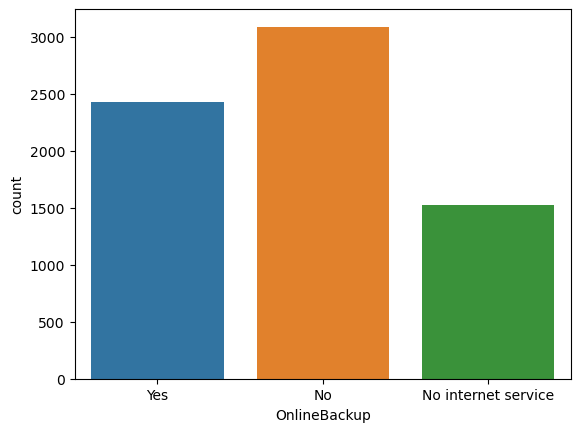

                     OnlineBackup      Ratio
No                           3088  43.844952
Yes                          2429  34.488144
No internet service          1526  21.666903
##########################################


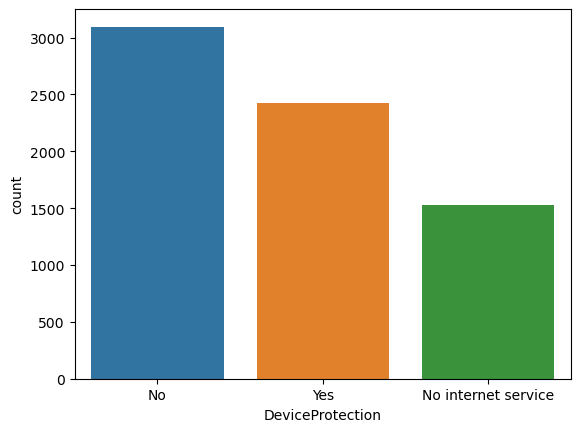

                     DeviceProtection      Ratio
No                               3095  43.944342
Yes                              2422  34.388755
No internet service              1526  21.666903
##########################################


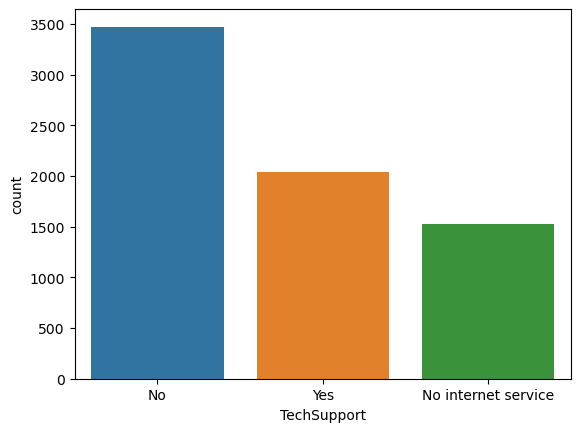

                     TechSupport      Ratio
No                          3473  49.311373
Yes                         2044  29.021724
No internet service         1526  21.666903
##########################################


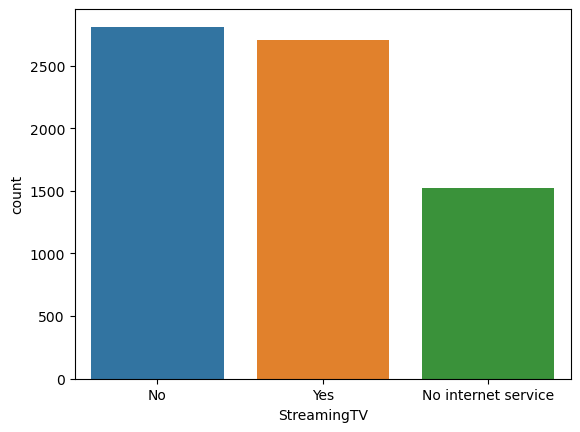

                     StreamingTV      Ratio
No                          2810  39.897771
Yes                         2707  38.435326
No internet service         1526  21.666903
##########################################


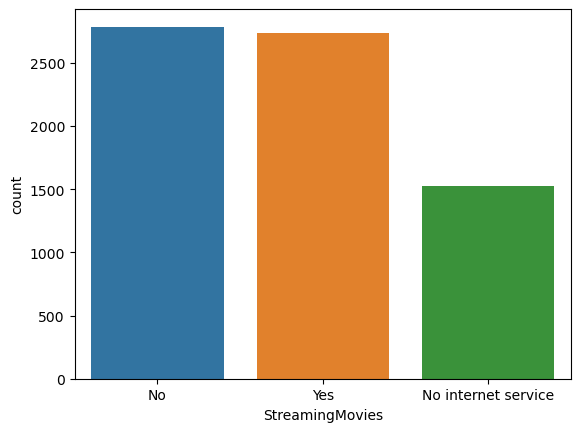

                     StreamingMovies      Ratio
No                              2785  39.542808
Yes                             2732  38.790288
No internet service             1526  21.666903
##########################################


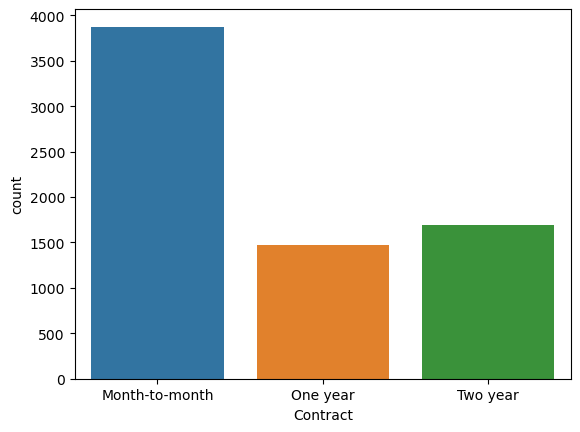

                Contract      Ratio
Month-to-month      3875  55.019168
Two year            1695  24.066449
One year            1473  20.914383
##########################################


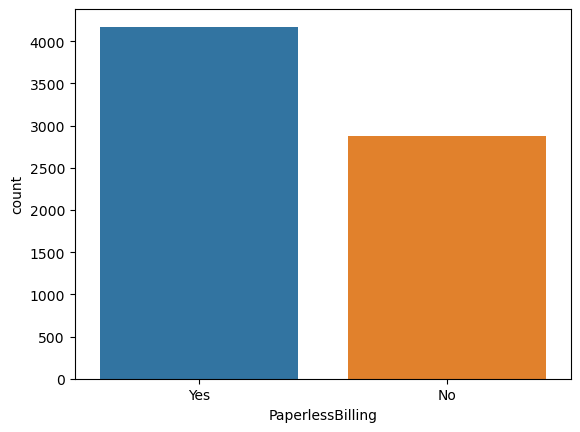

     PaperlessBilling      Ratio
Yes              4171  59.221922
No               2872  40.778078
##########################################


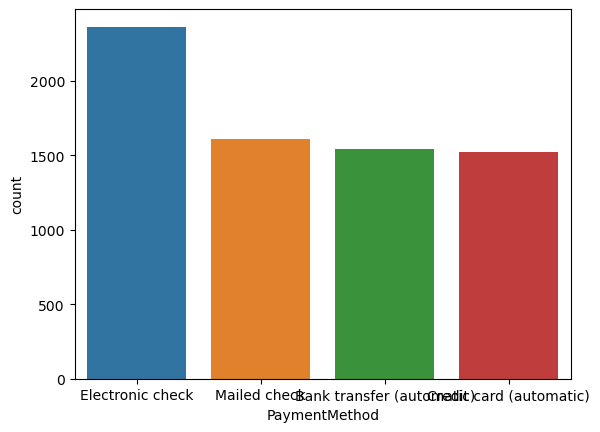

                           PaymentMethod      Ratio
Electronic check                    2365  33.579441
Mailed check                        1612  22.887974
Bank transfer (automatic)           1544  21.922476
Credit card (automatic)             1522  21.610109
##########################################


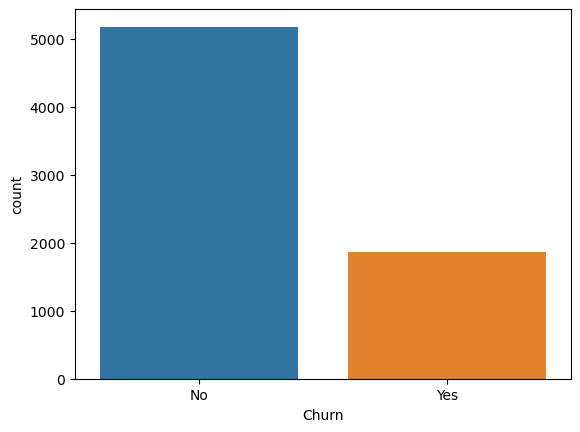

     Churn      Ratio
No    5174  73.463013
Yes   1869  26.536987
##########################################


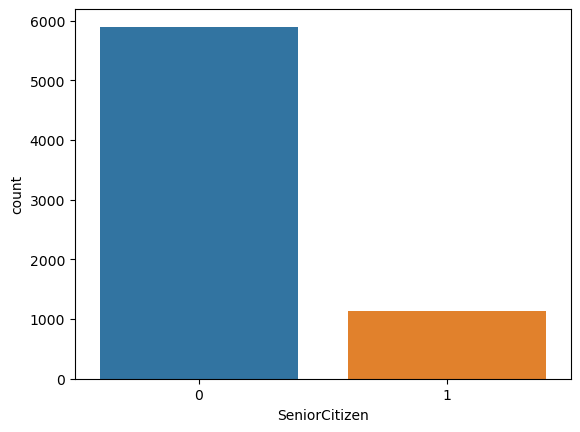

   SeniorCitizen      Ratio
0           5901  83.785319
1           1142  16.214681
##########################################


In [15]:
def cat_summary(dataframe, col_name, plot=False):
    
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show(block=True)
        print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
        print("##########################################")


for col in cat_cols:
    cat_summary(df, col,plot=True)

### Conclusion:
Gender: The number of male and female customers is almost equal.

Partner and Dependents: Slightly more customers do not have a partner or dependents.

PhoneService: Most customers (about 90%) have phone service.

MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies:
These columns have multiple categories, and the majority of customers do not have additional services such as online security, technical support, etc.

Contract: The most common contract type is month-to-month.

PaperlessBilling: The majority of customers (about 59%) use paperless billing.

PaymentMethod: The most common payment method is electronic check.

Churn: As shown by the high frequency of 'No' in the churn column, the churn rate is lower than the retention rate.

## Churn Analysis

In [16]:
df["Churn"].value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

In [17]:
df["Churn"] = df["Churn"].map({'No':0,'Yes':1})


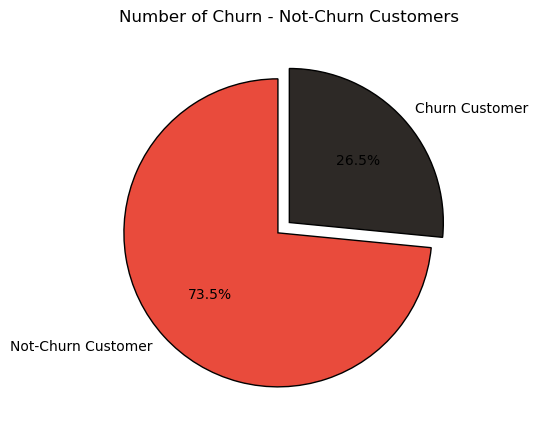

In [18]:
colors = ['#E94B3C','#2D2926']


l = list(df['Churn'].value_counts())
circle = [l[0] / sum(l) * 100,l[1] / sum(l) * 100]

fig = plt.subplots(figsize = (20,5))
plt.pie(circle,labels = ['Not-Churn Customer','Churn Customer'],autopct = '%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Churn - Not-Churn %');

plt.title('Number of Churn - Not-Churn Customers');
plt.show()

The dataset is unbalanced in a near about 3 : 1 ratio for Not-Churn : Churn customers!

Due to this, predictions will be biased towards Not-Churn customers.

Visualizations will also display this bias!

The Customer Churn Distribution chart and the calculated churn rate provide the following information:

Approximately 73.46% of customers did not churn, indicating that the majority are stable customers.

Approximately 26.54% of customers churned; this is a significant rate and may be a cause for concern for the business.

This churn rate highlights the importance of understanding the factors that contribute to customer churn. Businesses can use this information to develop strategies aimed at improving customer retention.

## Categorical Variables vs Target Variable (Churn):


Next, let's analyze the distribution of some key categorical variables, especially those that might have a significant impact on churn, like Contract, InternetService, and PaymentMethod. 

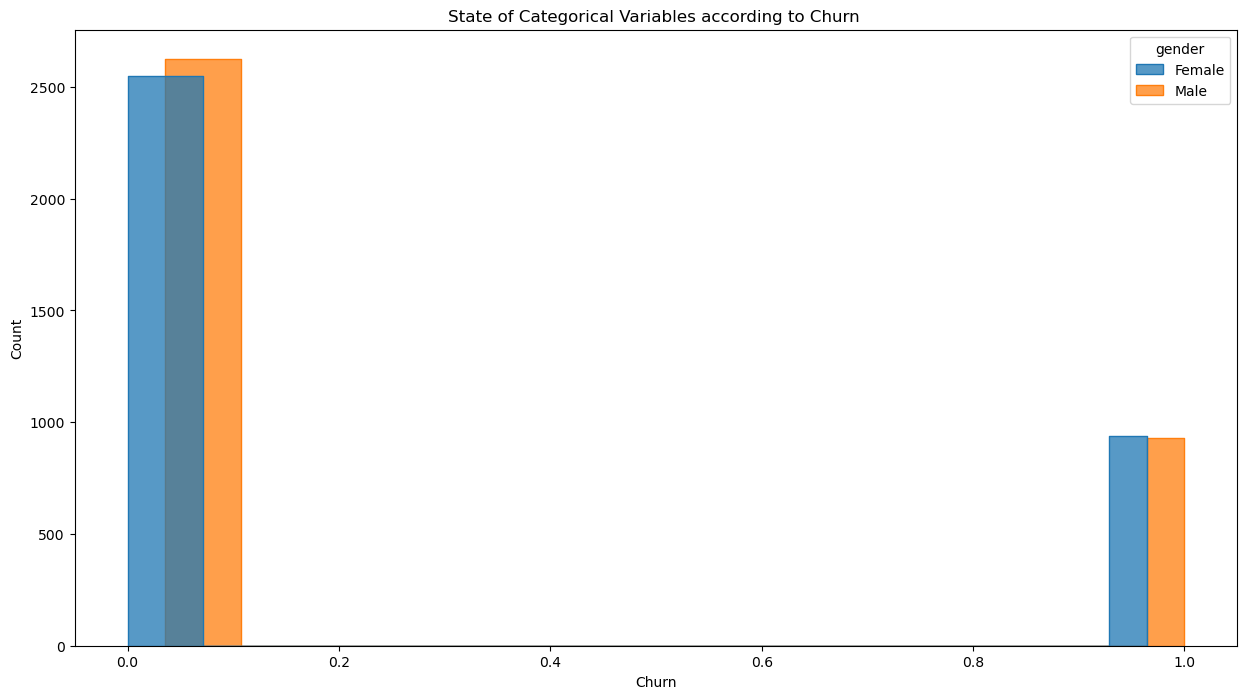

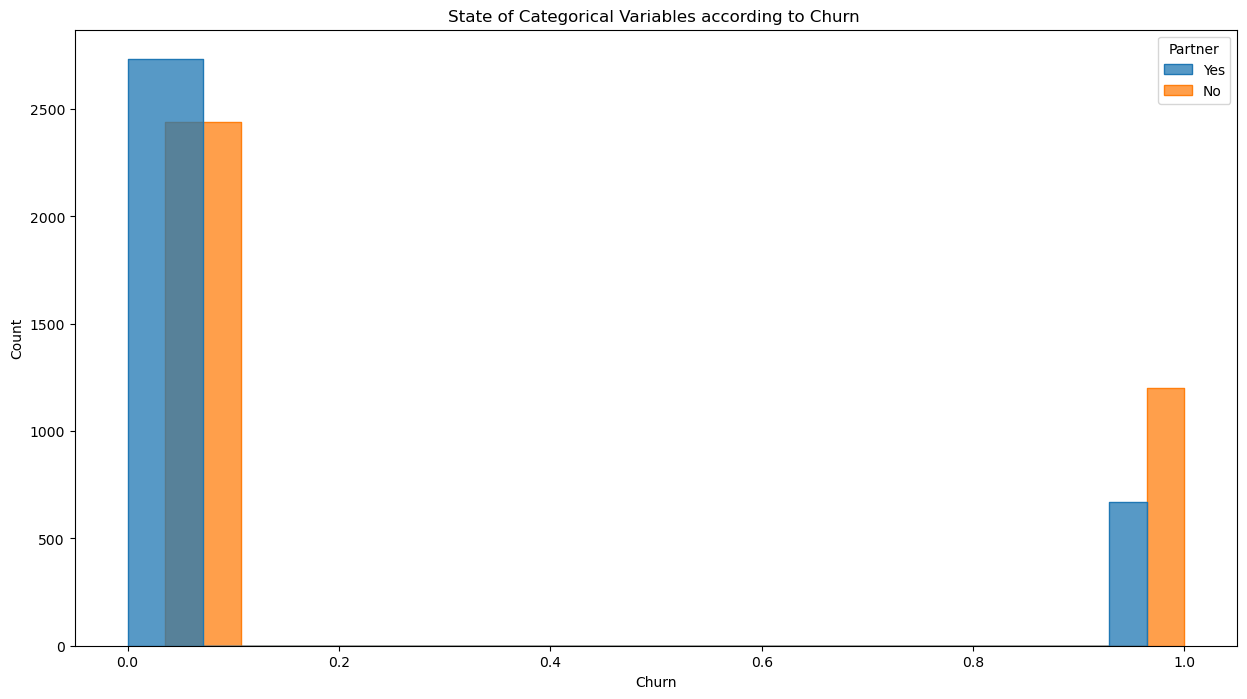

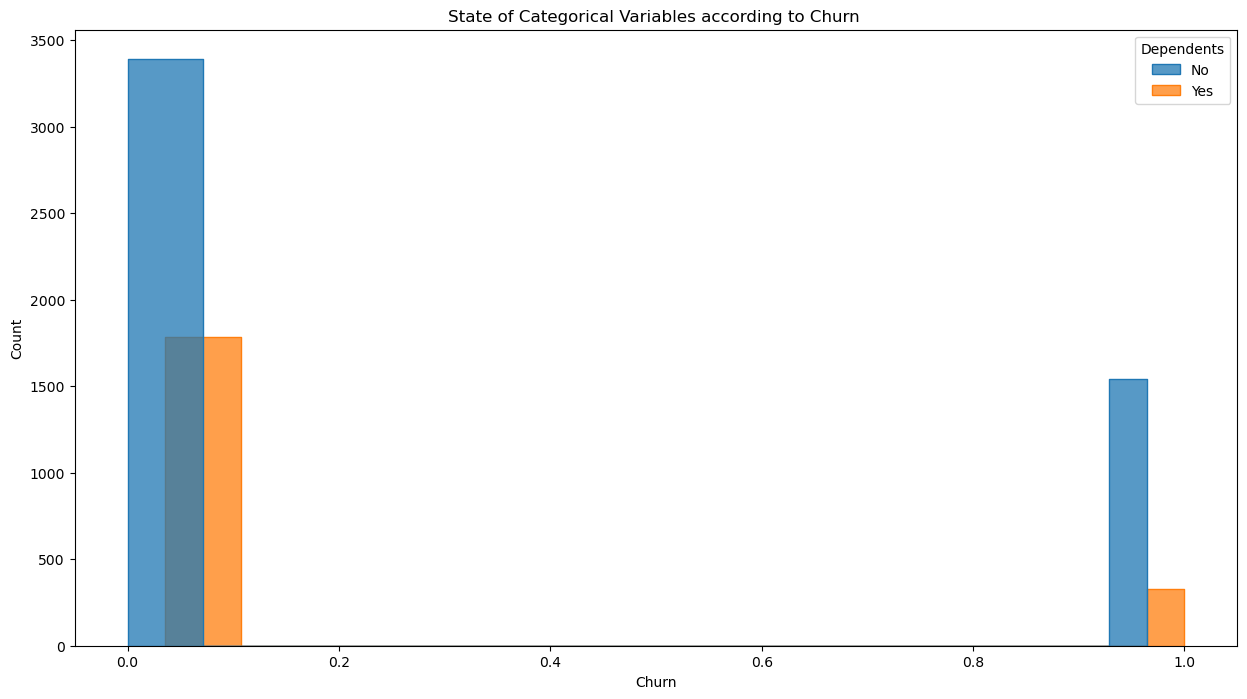

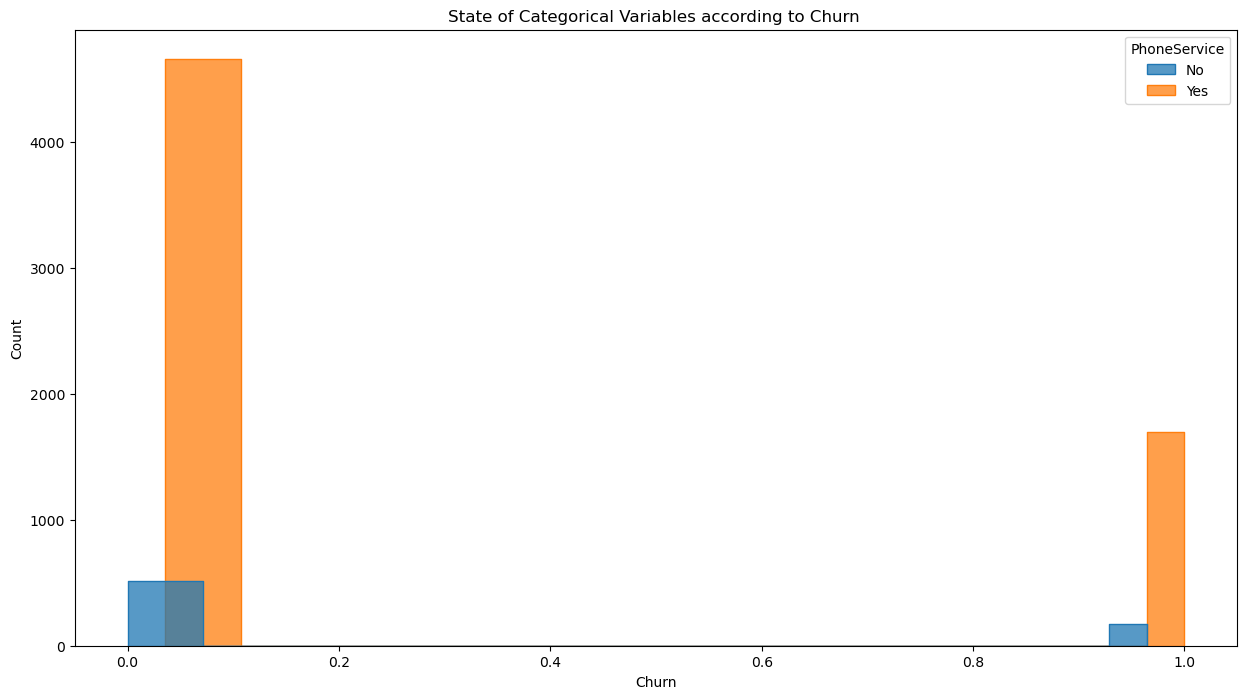

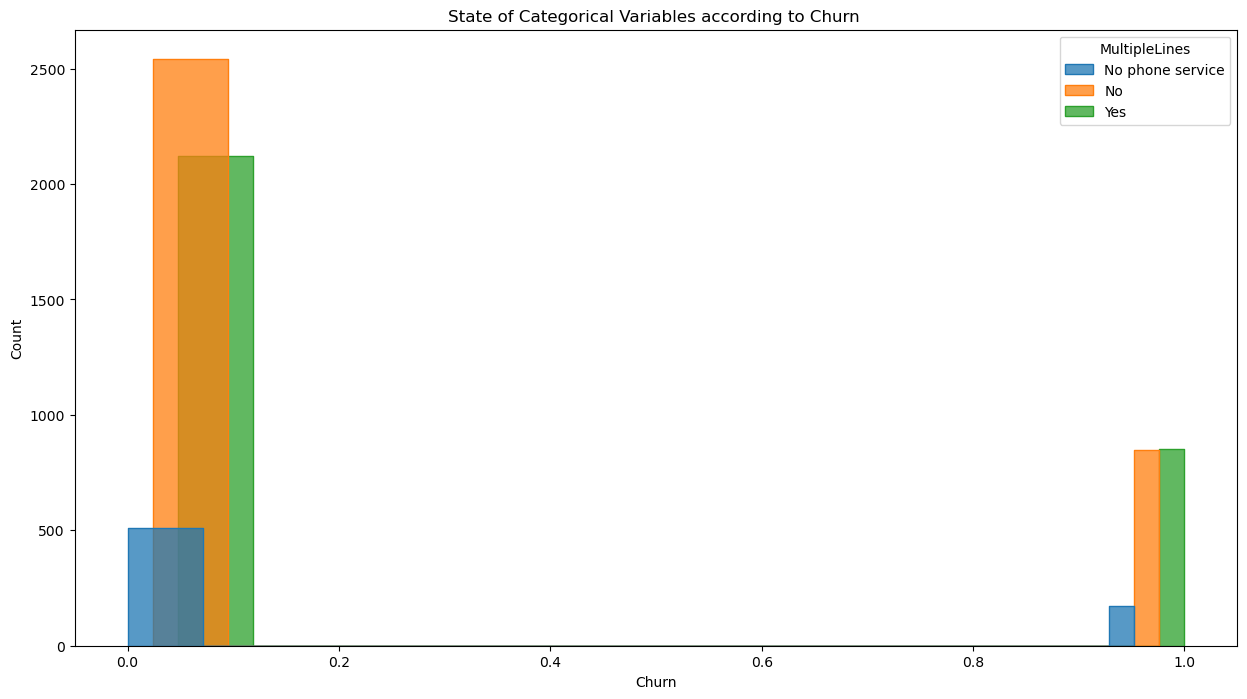

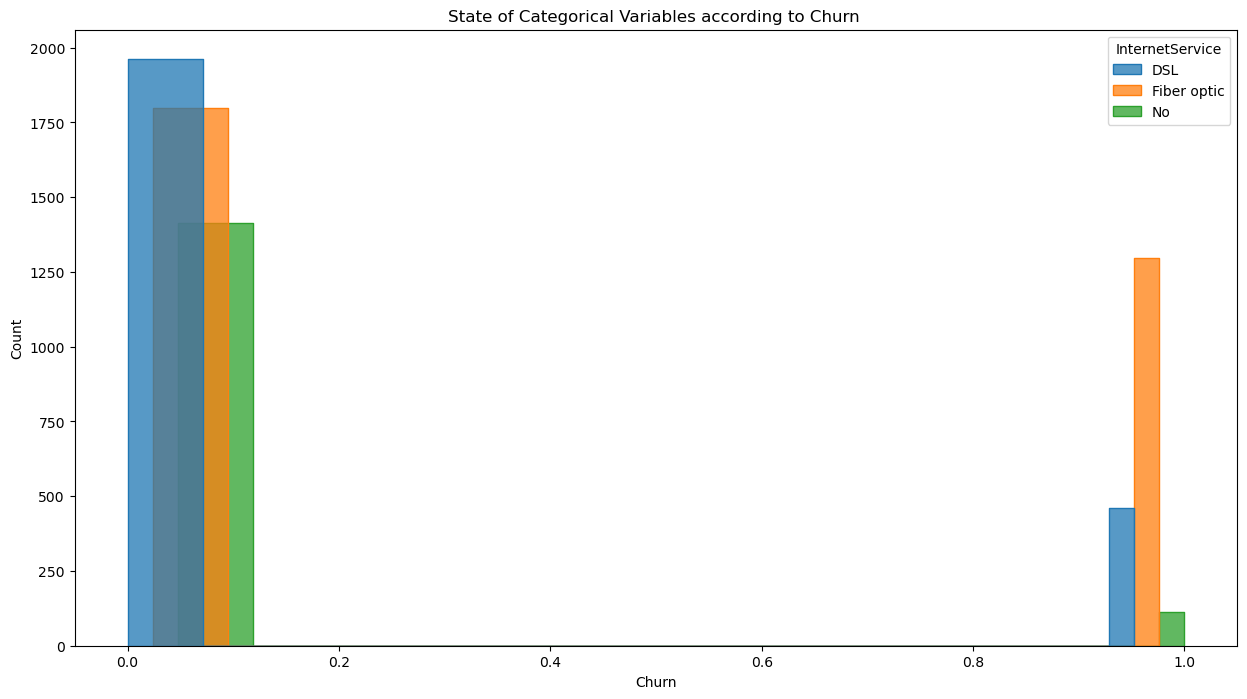

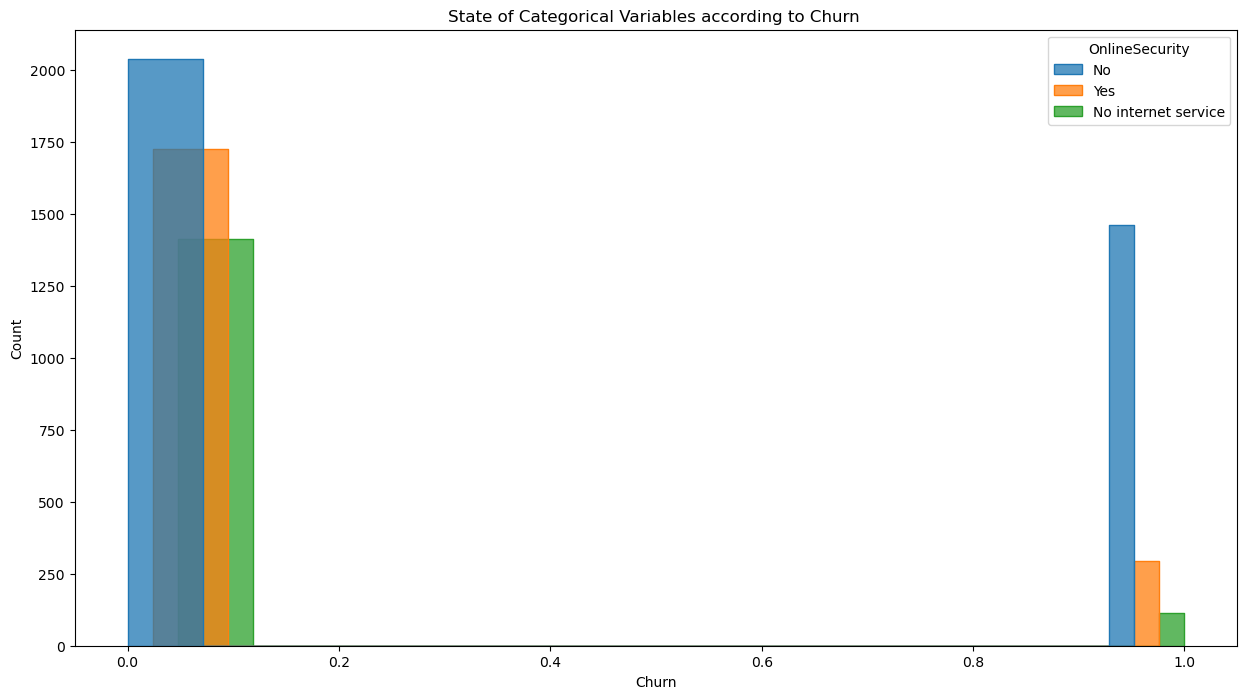

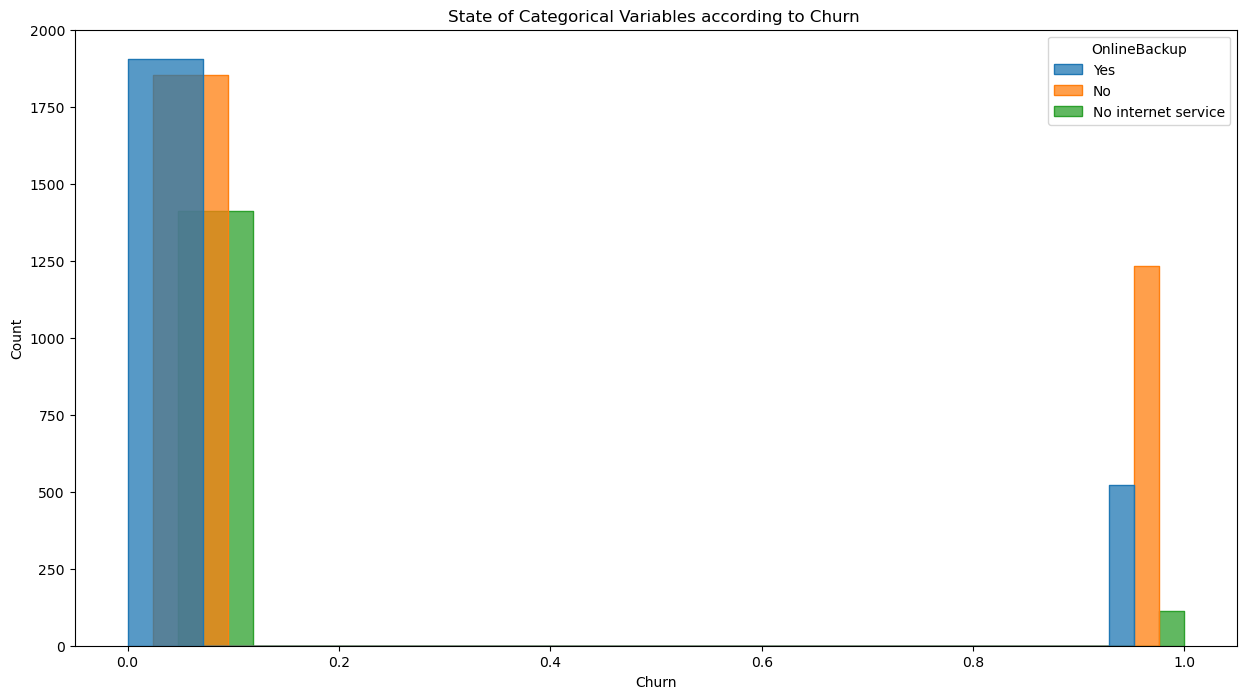

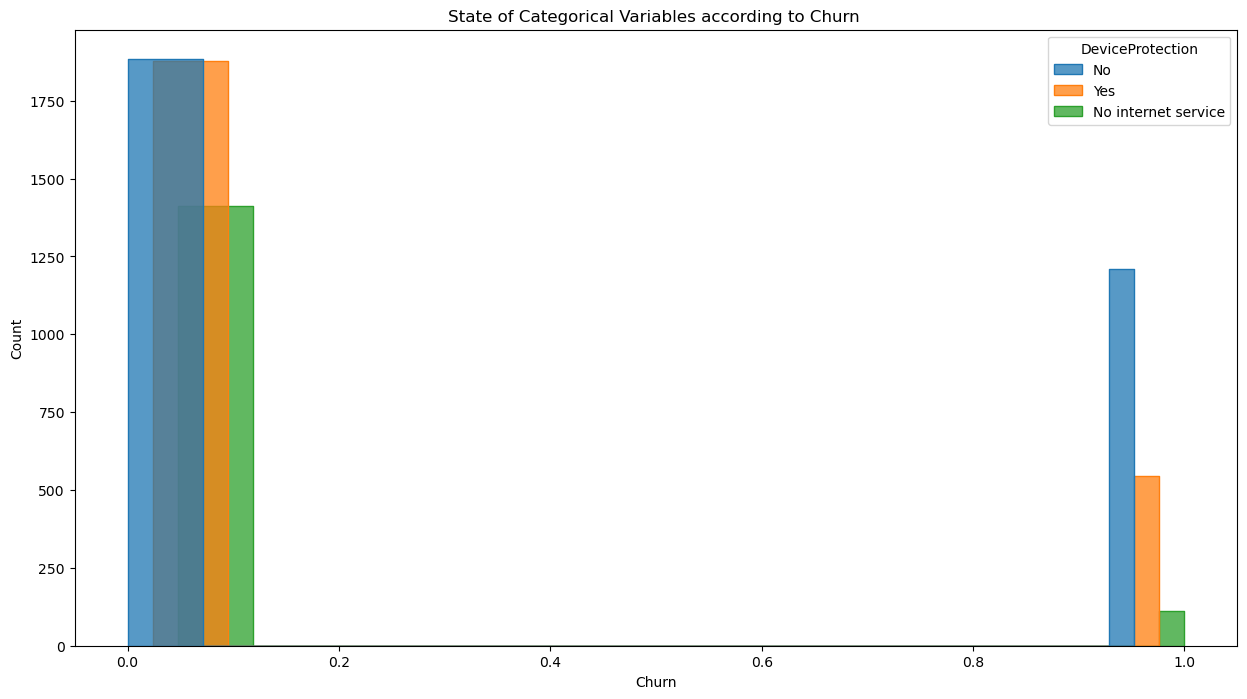

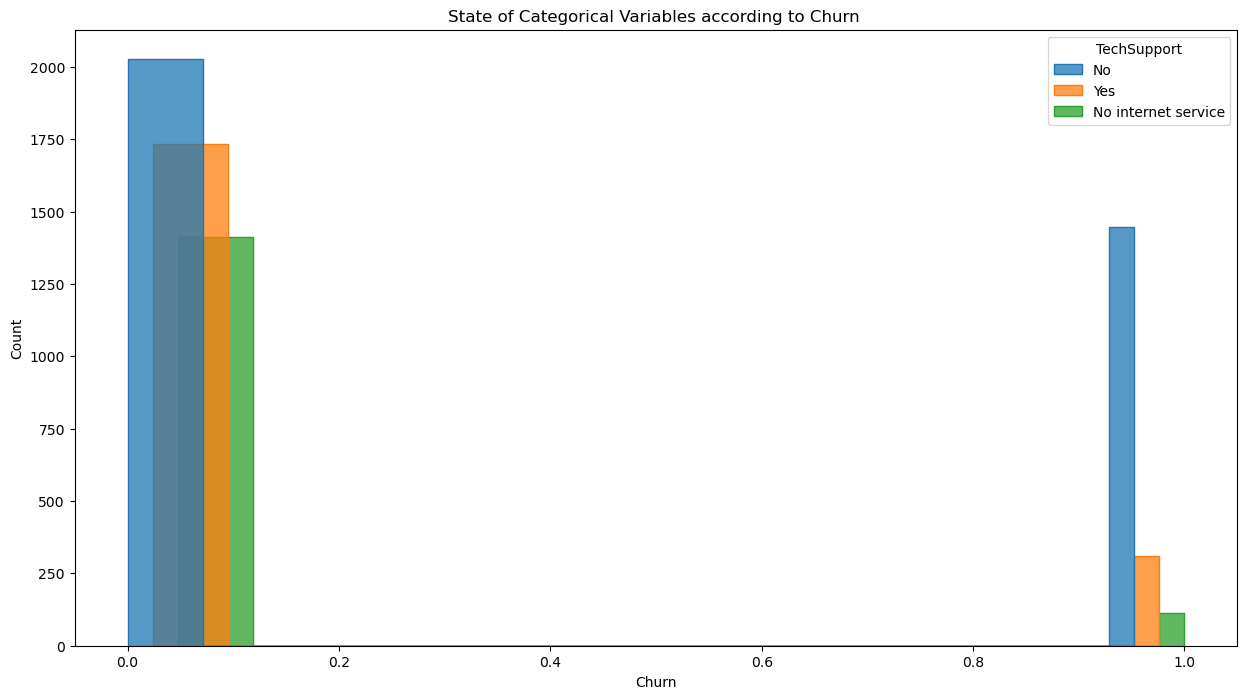

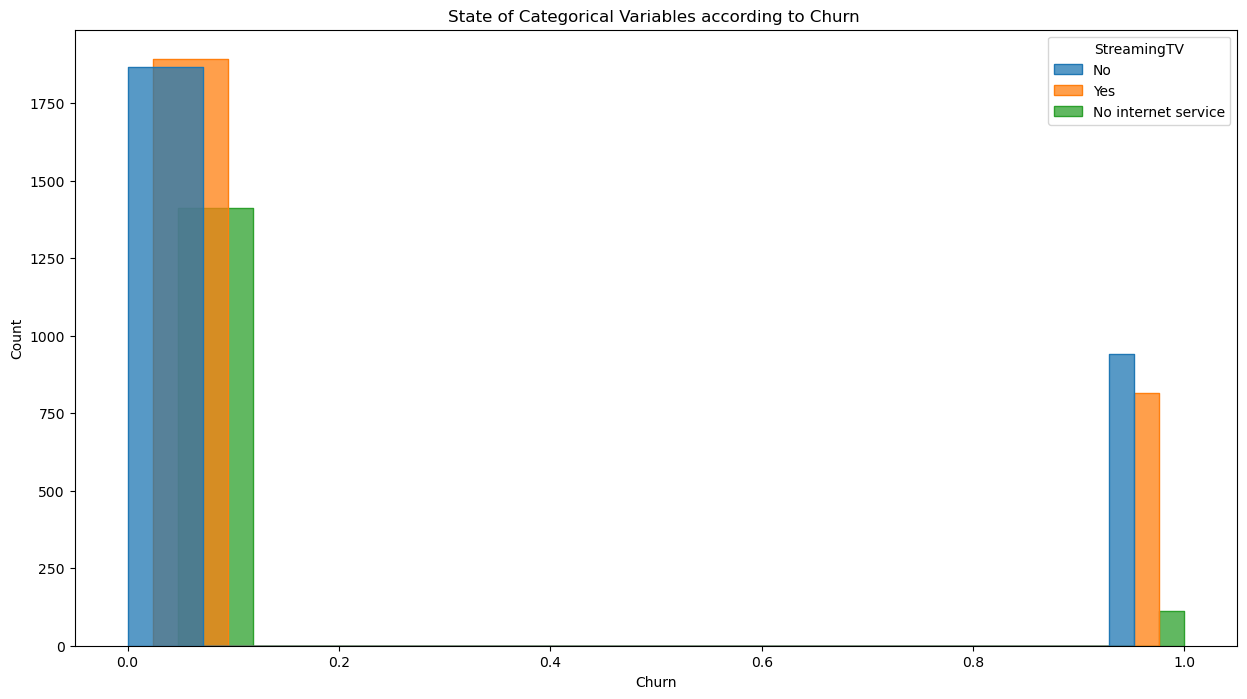

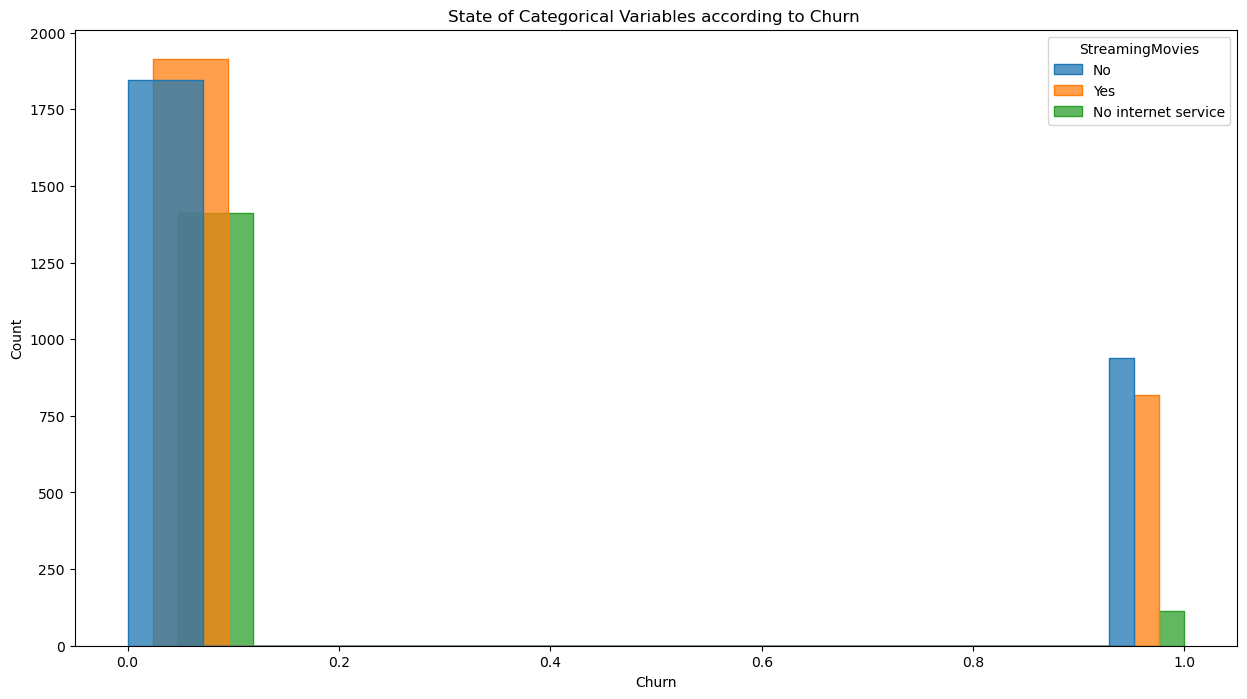

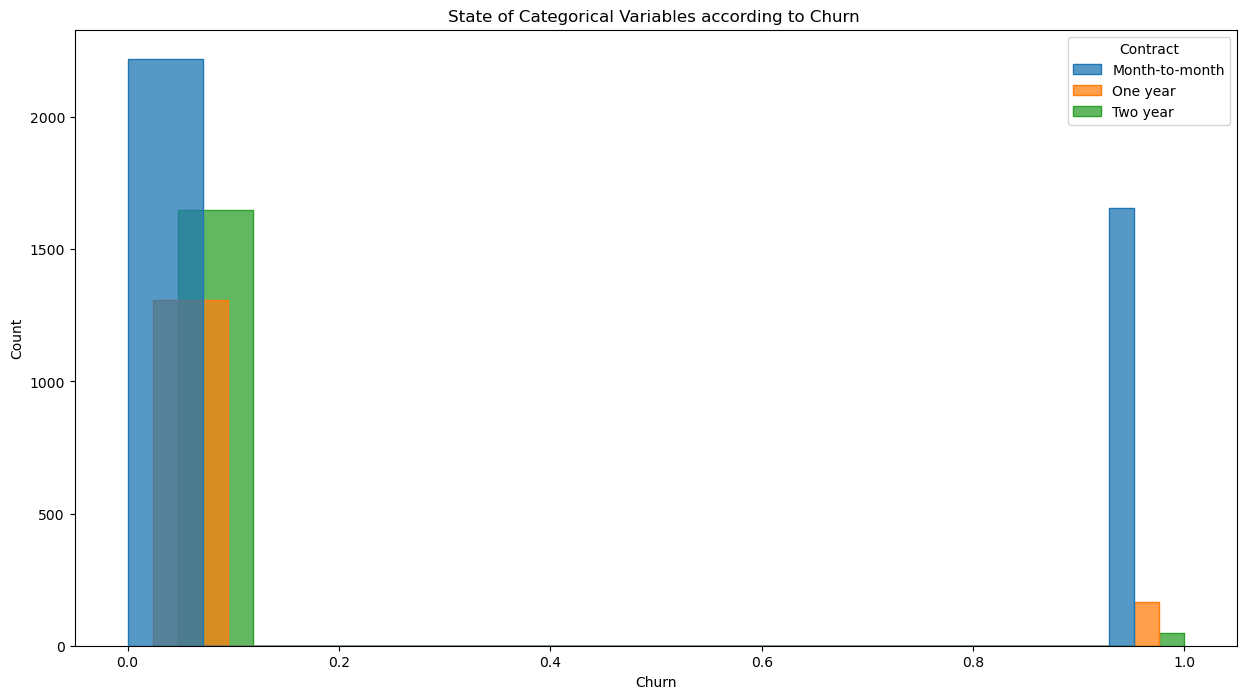

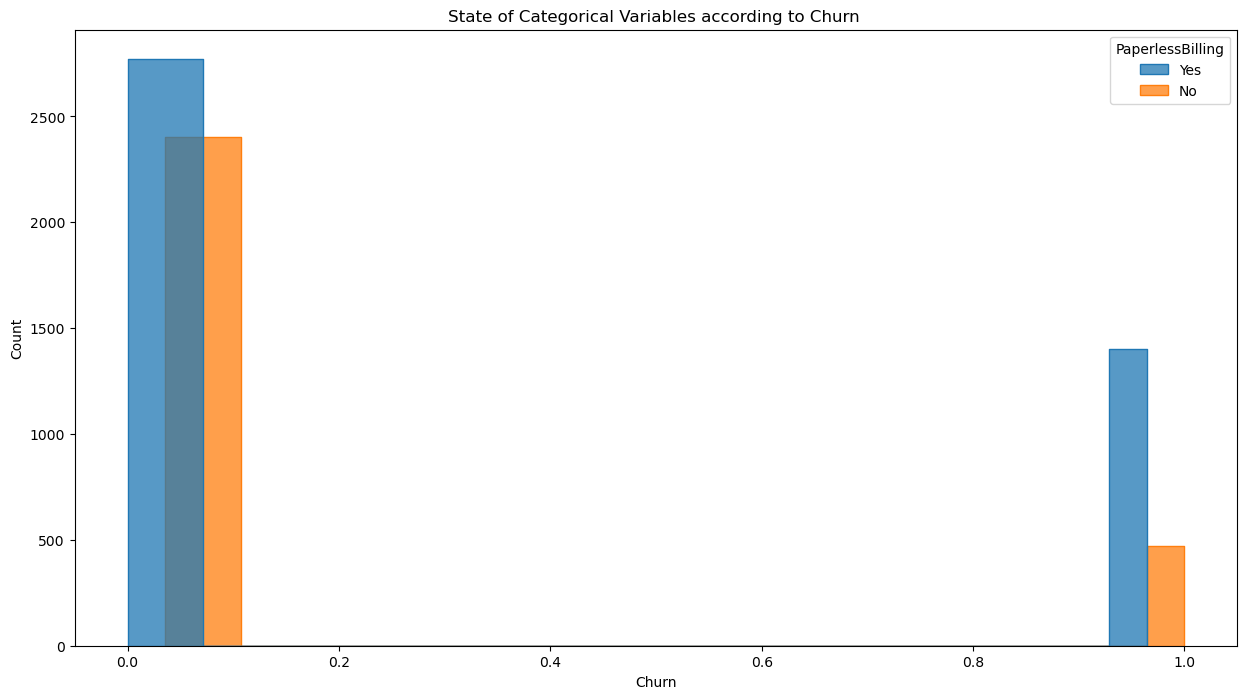

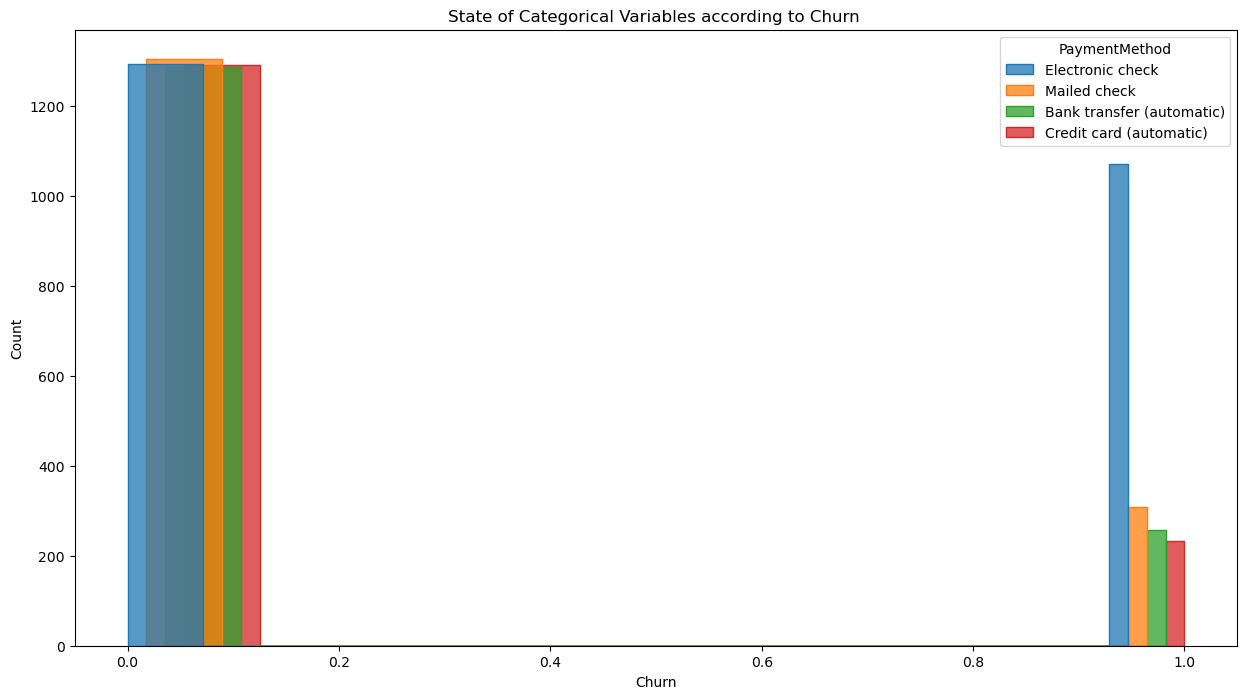

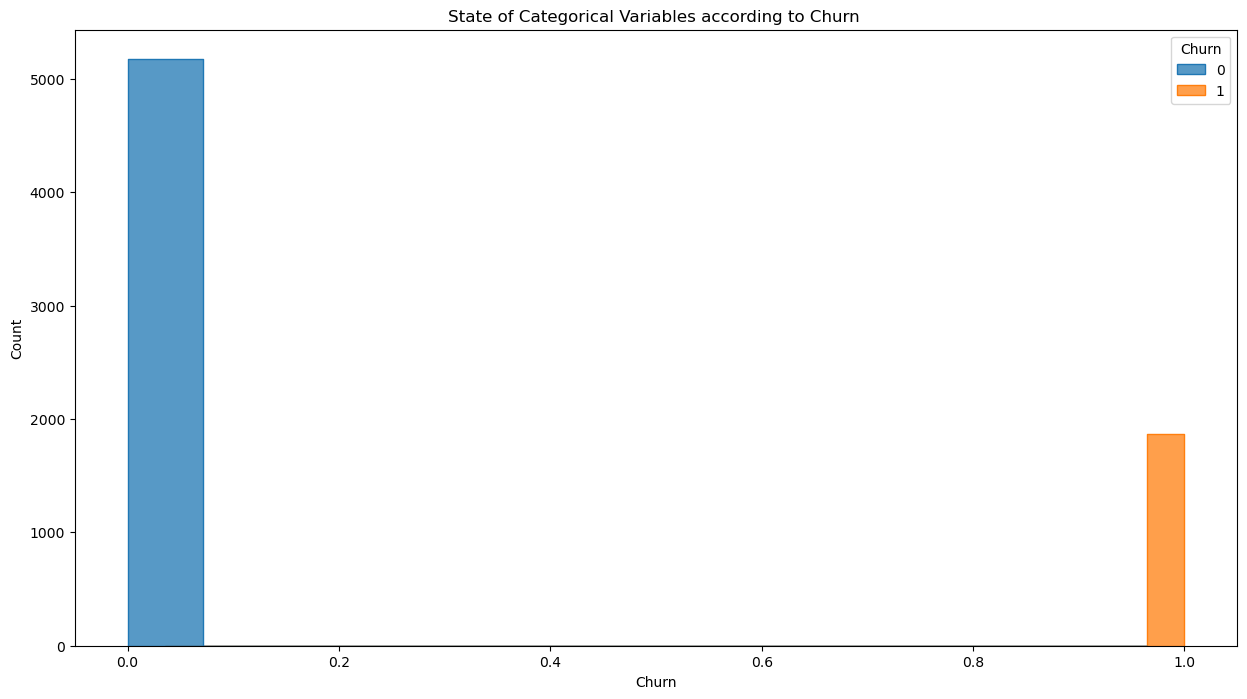

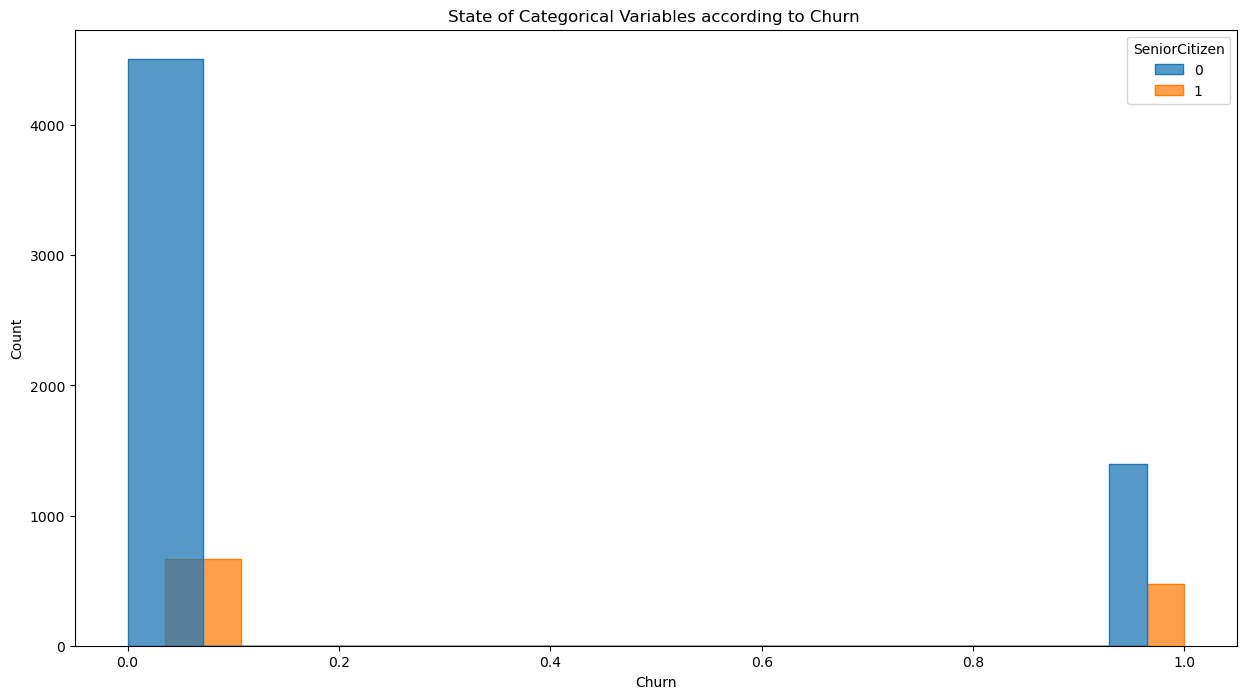

In [19]:
def target_vs_category_visual(dataframe,target, categorical_col):
    plt.figure(figsize=(15,8))
    sns.histplot(x=target,hue=categorical_col, data=dataframe,element="step",multiple="dodge")
    plt.title("State of Categorical Variables according to Churn ")
    plt.show()
    
def target_summary_with_cat(dataframe,target,categorical_col):
    print(pd.DataFrame({"CHURN_MEAN": dataframe.groupby(categorical_col)[target].mean()}))
    print(20*"-")


for col in cat_cols:
    target_vs_category_visual(df,"Churn",col)
    


Comments:

Customer churn is very similar for both male and female customers!

Likewise, the number of SeniorCitizen customers is quite low! Apart from this, we can observe an almost 40% churn rate among SeniorCitizen customers. This corresponds to a total of 476 customers out of 1,142 SeniorCitizen customers.

Customers living with a partner experienced less churn compared to those who do not live with a partner.

Similarly, customers who do not have dependents show a higher churn rate!

* For Phone Service, even though some customers do not have phone service, more customers were retained compared to those who churned.

* For Multiple Lines, the churn rate is the same regardless of whether multiple lines are available or not.

* A large number of customers have shown resistance to the use of fiber optic cables for internet service. Conversely, the chart above shows that customers prefer to use DSL for Internet Service!

* StreamingTV and StreamingMovies show the same pattern. Many customers churned regardless of whether they were subscribed to StreamingTV or StreamingMovies.

* When it comes to services offered to customers, OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport are very important according to the visualizations above!

* A large number of customers switched their service provider when these features were not adequately available.

* Customer churn is quite high for Month-to-Month Contracts. The reason is likely that customers test the various services offered to them and therefore try the 1-month service to save money!

* Another reason may be the inconsistent overall experience with internet service, streaming service, and phone service. Every customer has different priorities, and if even one of the three is not satisfactory, the entire service is cancelled!

* Paperless Billing shows that many customers churned. This is likely due to some payment issues or receipt-related problems.

* Customers were clearly unhappy with the Electronic Check payment method. Out of 2,365 bills paid using electronic checks, a surprising 1,071 customers churned because of this payment method. The company definitely needs to fix

* the electronic check method or make it smooth and user-friendly.

### Categorical Variables for Churn mean

In [20]:
for col in cat_cols:
    target_summary_with_cat(df,"Churn",col)

        CHURN_MEAN
gender            
Female    0.269209
Male      0.261603
--------------------
         CHURN_MEAN
Partner            
No         0.329580
Yes        0.196649
--------------------
            CHURN_MEAN
Dependents            
No            0.312791
Yes           0.154502
--------------------
              CHURN_MEAN
PhoneService            
No              0.249267
Yes             0.267096
--------------------
                  CHURN_MEAN
MultipleLines               
No                  0.250442
No phone service    0.249267
Yes                 0.286099
--------------------
                 CHURN_MEAN
InternetService            
DSL                0.189591
Fiber optic        0.418928
No                 0.074050
--------------------
                     CHURN_MEAN
OnlineSecurity                 
No                     0.417667
No internet service    0.074050
Yes                    0.146112
--------------------
                     CHURN_MEAN
OnlineBackup                

## Group 1 : Customer Information :
gender | SeniorCitizen | Partner | Dependents


In [21]:
gender = df[df['Churn'] == 1]['gender'].value_counts()
gender = [gender[0] / sum(gender) * 100, gender[1] / sum(gender) * 100] # Female / Male

seniorcitizen = df[df['Churn'] == 1]['SeniorCitizen'].value_counts()
seniorcitizen = [seniorcitizen[0] / sum(seniorcitizen) * 100,seniorcitizen[1] / sum(seniorcitizen) * 100] # No - Yes

partner = df[df['Churn'] == 1]['Partner'].value_counts()
partner = [partner[0] / sum(partner) * 100,partner[1] / sum(partner) * 100] # No - Yes

dependents = df[df['Churn'] == 1]['Dependents'].value_counts()
dependents = [dependents[0] / sum(dependents) * 100,dependents[1] / sum(dependents) * 100] # No - Yes

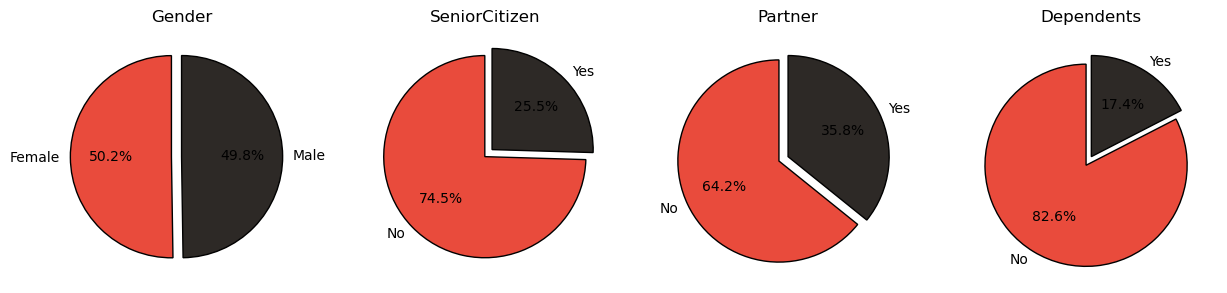

In [22]:
ax,fig = plt.subplots(nrows = 1,ncols = 4,figsize = (15,15))

plt.subplot(1,4,1)
plt.pie(gender,labels = ['Female','Male'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Gender');

plt.subplot(1,4,2)
plt.pie(seniorcitizen,labels = ['No', 'Yes'],autopct='%1.1f%%',startangle = 90,explode = (0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('SeniorCitizen');

plt.subplot(1,4,3)
plt.pie(partner,labels = ['No','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Partner');

plt.subplot(1,4,4)
plt.pie(dependents,labels = ['No','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Dependents');

We observe a clear 50–50 split between male and female customers who switched services.
Therefore, the reason for switching is related to something about the service itself or a process that customers reacted poorly to!

75% of the customers who churned are not Senior Citizens!
This is important information that the company should pay attention to.

Customers who live alone have discontinued the services.
According to the Partner & Dependents data, about 73.4% of the customers who churned were living alone.

## Group 2: Services Subscribed by the Customer :¶
PhoneService | MultipleLines | InternetService | StreamingTV | StreamingMovies |¶


In [23]:
phoneservice = df[df['Churn'] == 1]['PhoneService'].value_counts()
phoneservice = [phoneservice[0] / sum(phoneservice) * 100, phoneservice[1] / sum(phoneservice) * 100] # No - Yes

multiplelines = df[df['Churn'] == 1]['MultipleLines'].value_counts()
multiplelines = [multiplelines[0] / sum(multiplelines) * 100,multiplelines[1] / sum(multiplelines) * 100, multiplelines[2] / sum(multiplelines) * 100] # No - No Phone Service - Yes 

internetservice = df[df['Churn'] == 1]['InternetService'].value_counts()
internetservice = [internetservice[0] / sum(internetservice) * 100,internetservice[1] / sum(internetservice) * 100, internetservice[2] / sum(internetservice) * 100] # DSL - Fiber Optic - No 

streamingtv = df[df['Churn'] == 1]['StreamingTV'].value_counts()
streamingtv = [streamingtv[0] / sum(streamingtv) * 100,streamingtv[1] / sum(streamingtv) * 100, streamingtv[2] / sum(streamingtv) * 100] # No - No Internet Service - Yes 

streamingmovies = df[df['Churn'] == 1]['StreamingMovies'].value_counts()
streamingmovies = [streamingmovies[0] / sum(streamingmovies) * 100,streamingmovies[1] / sum(streamingmovies) * 100, streamingmovies[2] / sum(streamingmovies) * 100] # No - No Internet Service - Yes 

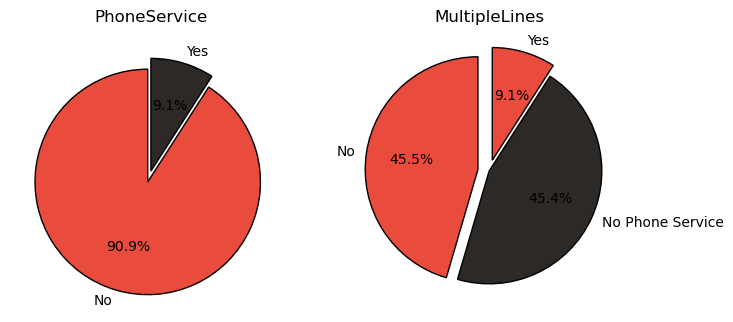

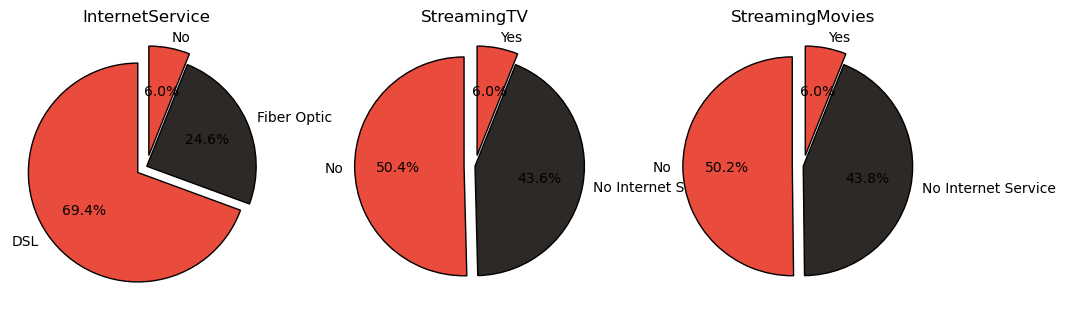

In [24]:
ax,fig = plt.subplots(nrows = 1,ncols = 2,figsize = (8,8))

plt.subplot(1,2,1)
plt.pie(phoneservice,labels = ['No', 'Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('PhoneService');

plt.subplot(1,2,2)
plt.pie(multiplelines,labels = ['No','No Phone Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('MultipleLines');

ax,fig = plt.subplots(nrows = 1,ncols = 3,figsize = (12,12))

plt.subplot(1,3,1)
plt.pie(internetservice,labels = ['DSL', 'Fiber Optic','No'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('InternetService');

plt.subplot(1,3,2)
plt.pie(streamingtv,labels = ['No', 'No Internet Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('StreamingTV');

plt.subplot(1,3,3)
plt.pie(streamingmovies,labels = ['No', 'No Internet Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('StreamingMovies');

* Even though Phone Service is provided, a large percentage of customers switched away from the phone service!

* Similarly, the availability of Multiple Lines was not important, since customers cancelled their subscriptions regardless of whether they had multiple lines or not!

* Customers clearly did not appreciate the use of Fiber Optic cables for providing Internet Service, with a definite churn rate of 70% for this service approach!

* For StreamingTV and StreamingMovies, customers who did not have these services definitely cancelled their subscriptions—but even among customers who did consume streaming content, an average of 43.7% still switched their subscription.

## Group 2: Services Subscribed by the Customer
OnlineSecurity | OnlineBackup | DeviceProtection | TechSupport 


In [25]:
onlinesecurity = df[df['Churn'] == 1]['OnlineSecurity'].value_counts()
onlinesecurity = [onlinesecurity[0] / sum(onlinesecurity) * 100,onlinesecurity[1] / sum(onlinesecurity) * 100, onlinesecurity[2] / sum(onlinesecurity) * 100] # No - No Internet Service - Yes 

onlinebackup = df[df['Churn'] == 1]['OnlineBackup'].value_counts()
onlinebackup = [onlinebackup[0] / sum(onlinebackup) * 100,onlinebackup[1] / sum(onlinebackup) * 100, onlinebackup[2] / sum(onlinebackup) * 100] # No - No Internet Service - Yes 

deviceprotection = df[df['Churn'] == 1]['DeviceProtection'].value_counts()
deviceprotection = [deviceprotection[0] / sum(deviceprotection) * 100,deviceprotection[1] / sum(deviceprotection) * 100, deviceprotection[2] / sum(deviceprotection) * 100] # No - No Internet Service - Yes 

techsupport = df[df['Churn'] == 1]['TechSupport'].value_counts()
techsupport = [techsupport[0] / sum(techsupport) * 100,techsupport[1] / sum(techsupport) * 100, techsupport[2] / sum(techsupport) * 100] # No - No Internet Service - Yes 

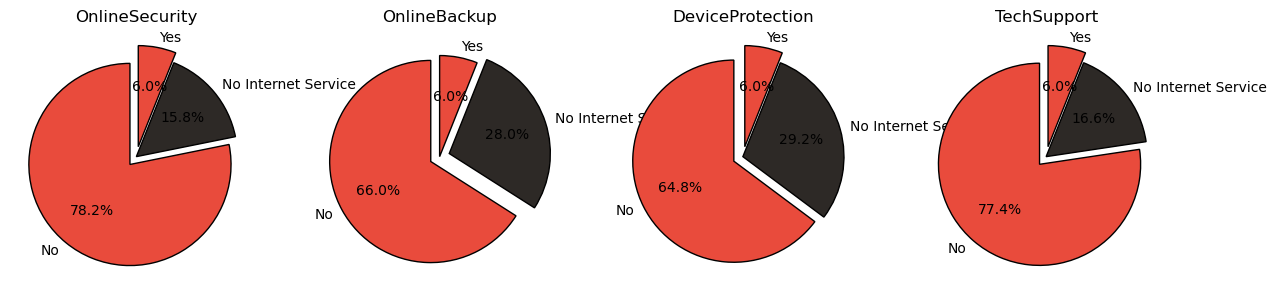

In [26]:
ax,fig = plt.subplots(nrows = 1,ncols = 4,figsize = (15,15))

plt.subplot(1,4,1)
plt.pie(onlinesecurity,labels = ['No', 'No Internet Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('OnlineSecurity');

plt.subplot(1,4,2)
plt.pie(onlinebackup,labels = ['No', 'No Internet Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('OnlineBackup');

plt.subplot(1,4,3)
plt.pie(deviceprotection,labels = ['No', 'No Internet Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('DeviceProtection');

plt.subplot(1,4,4)
plt.pie(techsupport,labels = ['No', 'No Internet Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('TechSupport');

The pie charts above highlight the importance of providing OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport, because on average 71.6% of customers discontinue their services due to the lack of these features!

## Group 3 : Contract | PaperlessBilling | PaymentMethod |¶


In [27]:
contract = df[df['Churn'] == 1]['Contract'].value_counts()
contract = [contract[0] / sum(contract) * 100, contract[1] / sum(contract) * 100, contract[2] / sum(contract) * 100] # Month-to-month - One year - Two year

paperlessbilling = df[df['Churn'] == 1]['PaperlessBilling'].value_counts()
paperlessbilling = [paperlessbilling[0] / sum(paperlessbilling) * 100,paperlessbilling[1] / sum(paperlessbilling) * 100] # No - Yes 

paymentmethod = df[df['Churn'] == 1]['PaymentMethod'].value_counts()
paymentmethod = [paymentmethod[0] / sum(paymentmethod) * 100, paymentmethod[1] / sum(paymentmethod) * 100, 
            paymentmethod[2] / sum(paymentmethod) * 100, paymentmethod[3] / sum(paymentmethod) * 100] 

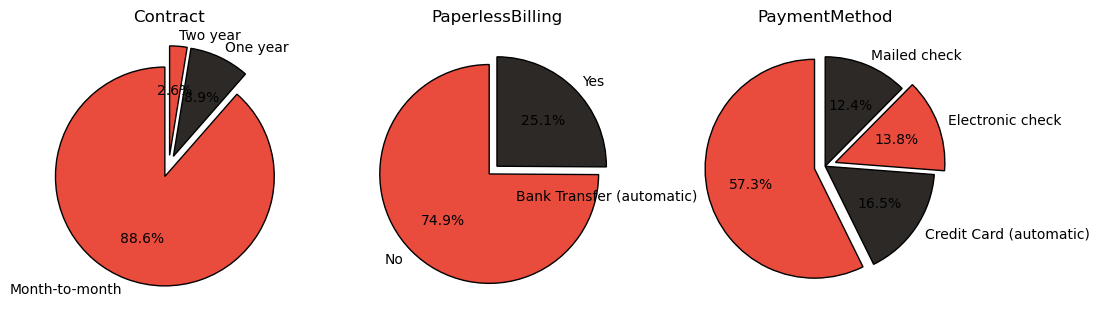

In [28]:
ax,fig = plt.subplots(nrows = 1,ncols = 3,figsize = (12,12))

plt.subplot(1,3,1)
plt.pie(contract,labels = ['Month-to-month','One year','Two year'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0.1,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Contract');

plt.subplot(1,3,2)
plt.pie(paperlessbilling,labels = ['No', 'Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('PaperlessBilling');

plt.subplot(1,3,3)
plt.pie(paymentmethod,labels = ['Bank Transfer (automatic)','Credit Card (automatic)','Electronic check','Mailed check'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('PaymentMethod');

### Comment

* Month-to-Month Contract duration has the dominant share when it comes to churn, accounting for a massive 88.6% customer loss!

* Paperless Billing does not seem to be liked by customers!

* Electronic Check definitely needs to be addressed, as it accounts for 57.3% of the churn. This is followed by Mailed Check, Bank Transfer (automatic), and Credit Card (automatic)!

### Numerical Variables vs Target Variable(Churn)

In [29]:
def target_summary_with_num(dataframe,target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col:"mean"}), end="\n\n")
    print("###################################")
    

for col in num_cols:
    target_summary_with_num(df,"Churn",col)

          tenure
Churn           
0      37.569965
1      17.979133

###################################
       MonthlyCharges
Churn                
0           61.265124
1           74.441332

###################################
       TotalCharges
Churn              
0       2549.911442
1       1531.796094

###################################


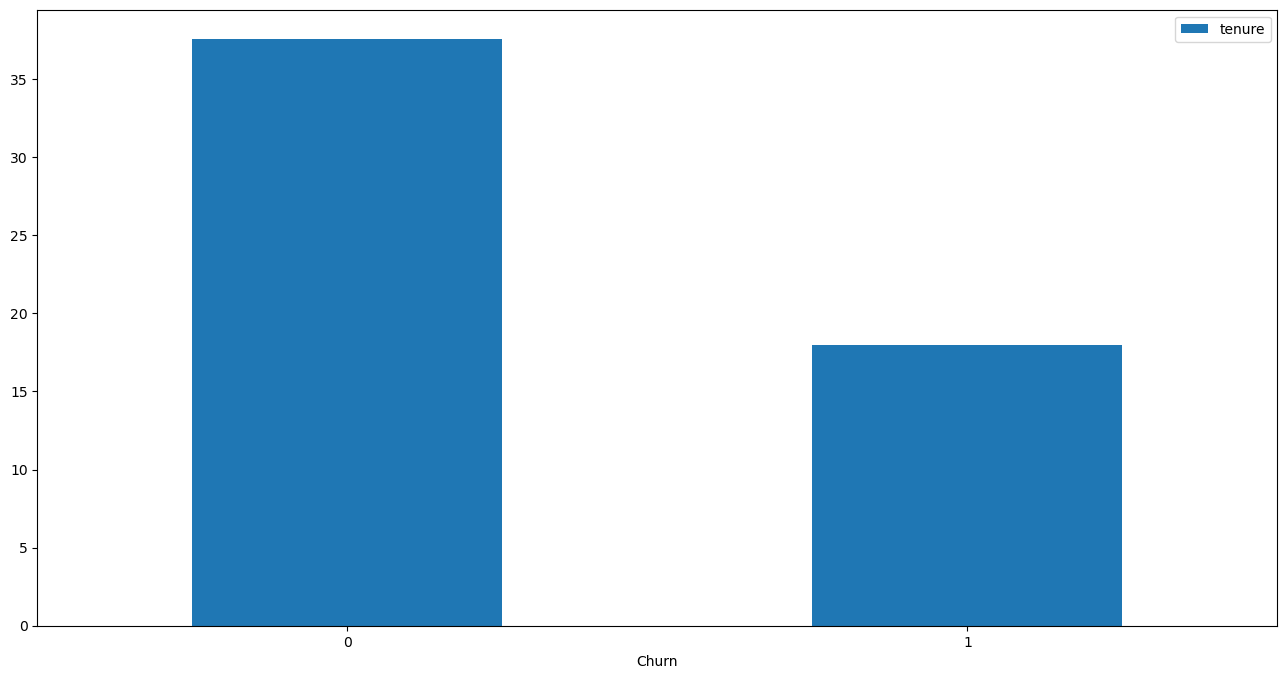

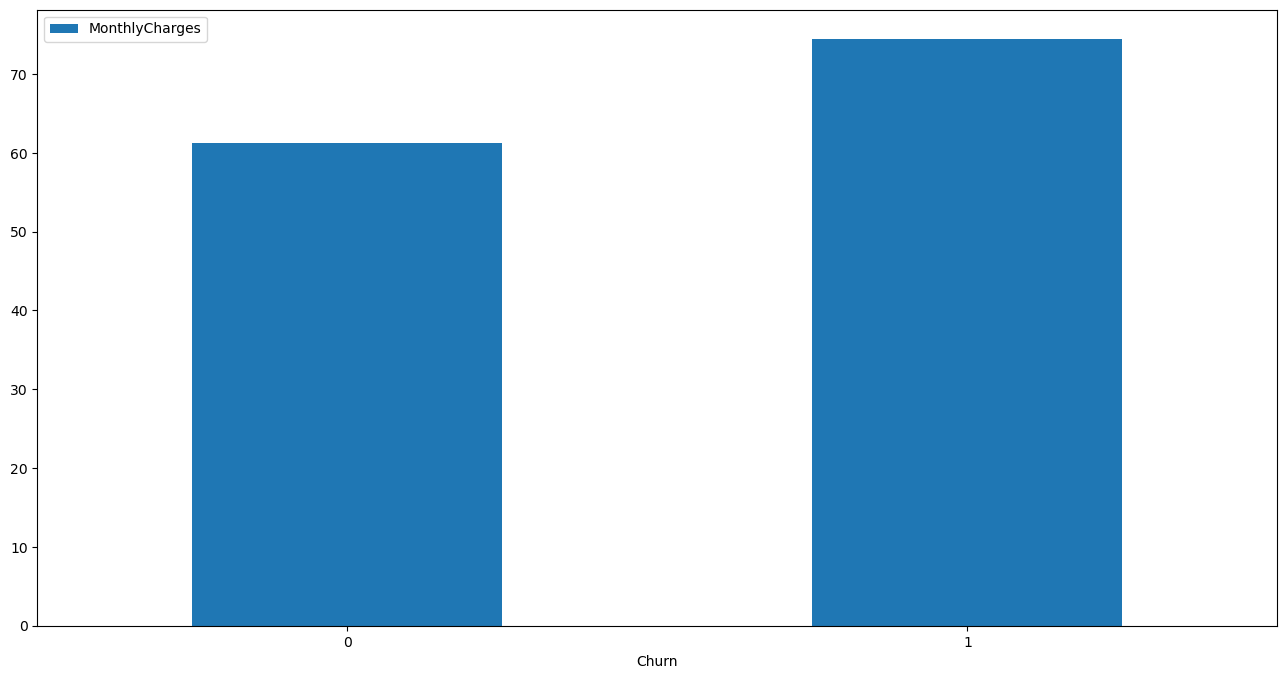

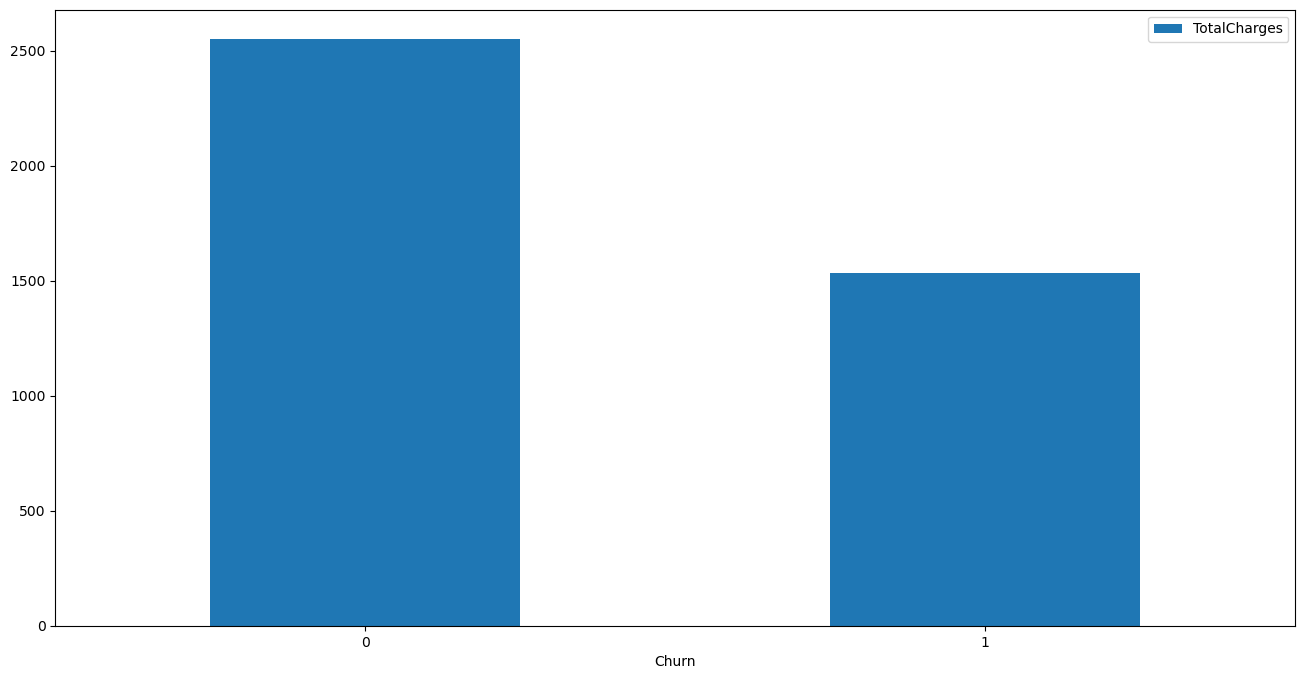

In [30]:
for col in num_cols:
    df.groupby('Churn').agg({col:'mean'}).plot(kind='bar', rot = 0,figsize=(16,8))

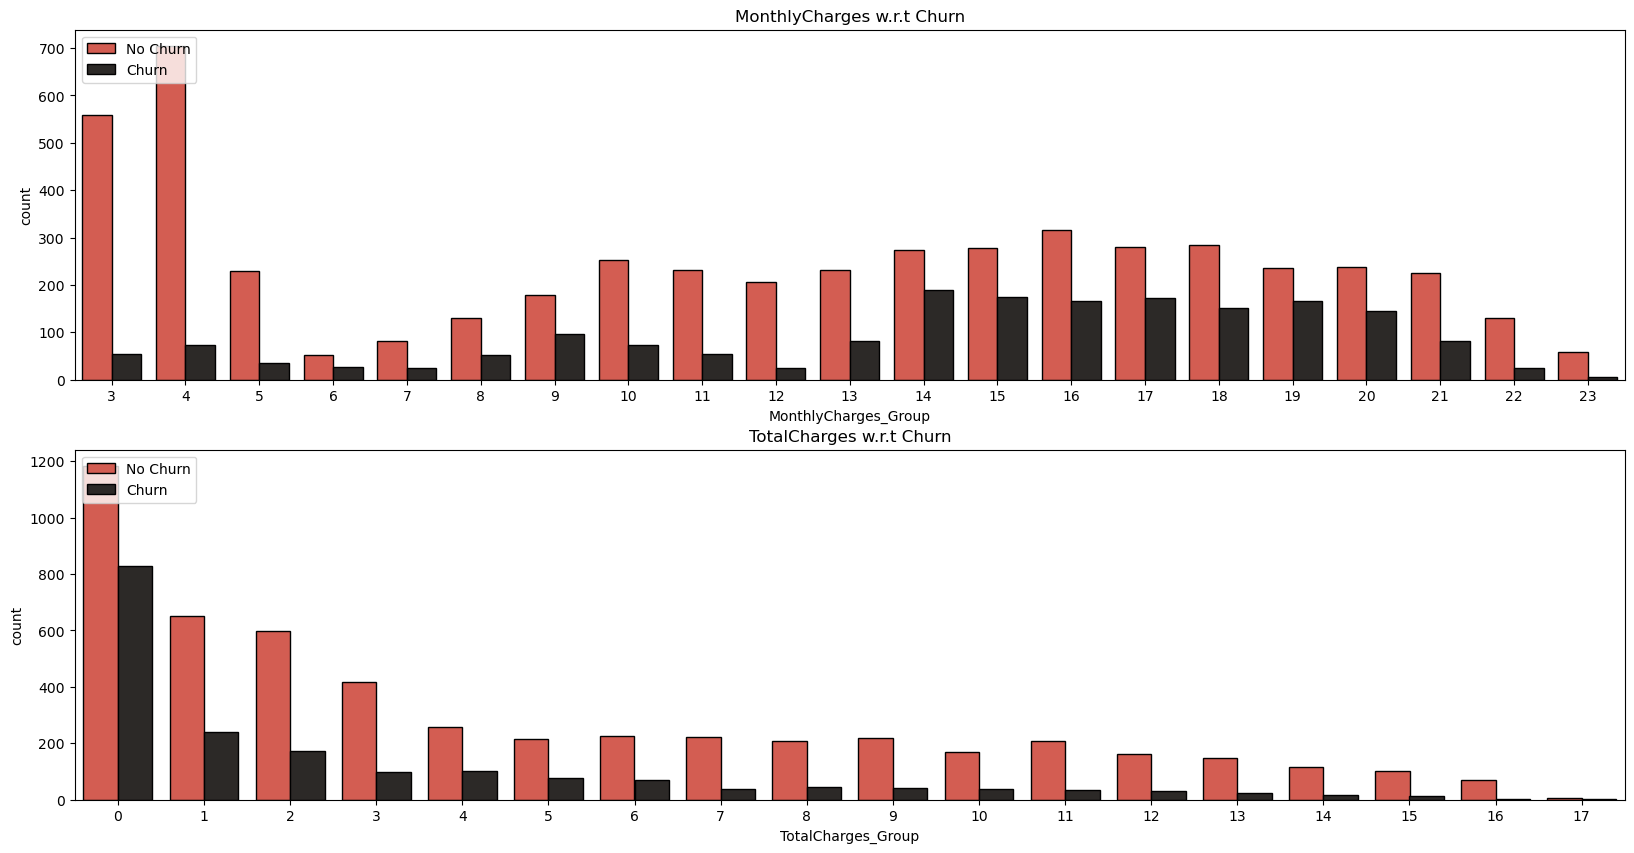

In [31]:
df['MonthlyCharges_Group'] = [int(i / 5) for i in df['MonthlyCharges']]
df['TotalCharges_Group'] = [int(i / 500) for i in df['TotalCharges']]

fig, ax = plt.subplots(nrows = 2,ncols = 1,figsize = (20,10))
for i in range(len(num_cols[1:])):
    plt.subplot(2,1,i+1)
    sns.countplot(x = num_cols[1 + i]+'_Group',data = df,hue = "Churn",palette = colors,edgecolor = 'black')
    plt.legend(['No Churn','Churn'],loc = 'upper left')
    title = num_cols[1 + i] + ' w.r.t Churn'
    plt.title(title);

Comment

For the MonthlyCharges group, the churn rate is high in the range of 65 (13×5) to 105 (21×5). This range of MonthlyCharges values caused customers to switch.

A very large number of customers discontinued the services when their TotalCharges were below 500.

## Numerical features vs Categorical features w.r.t Target variable (Churn)


In [32]:
l1 = ['gender','SeniorCitizen','Partner','Dependents'] # Customer Information
l2 = ['PhoneService','MultipleLines','InternetService','StreamingTV','StreamingMovies',
      'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport'] # Services Signed Up for!
l3 = ['Contract','PaperlessBilling','PaymentMethod'] # Payment Information

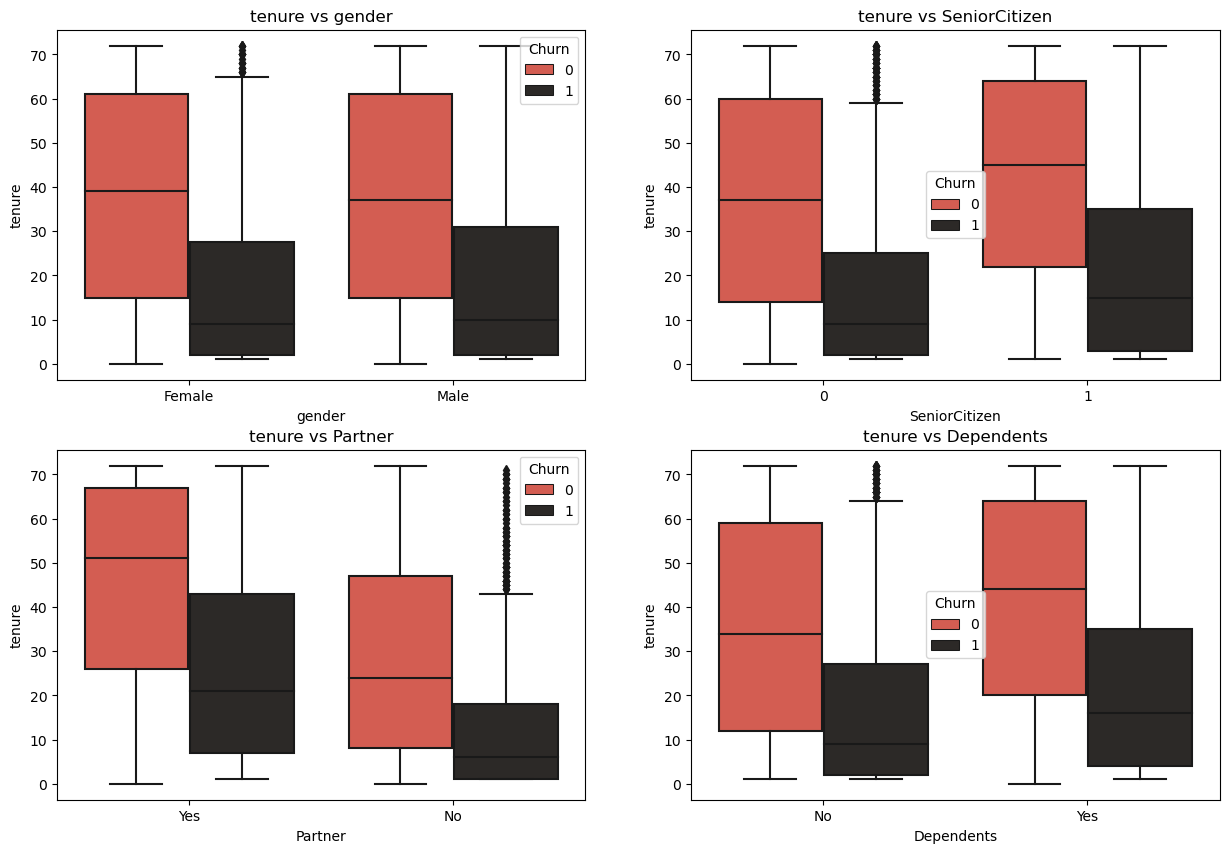

In [33]:
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (15,10))
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = l1[i],y = 'tenure',data = df,hue = 'Churn',palette = colors);
    plt.title('tenure vs ' + l1[i]);
    
    

Comments

The churn graphs for male and female customers are very similar.

SeniorCitizen customers discontinued the services for tenure values between 0 and 35 months. The 20–35 month range appears to be a kind of decision-making period for SeniorCitizen customers regarding whether to continue or switch.

Similarly, customers who have partners continued using the service for 5 to 45 months.

### tenure vs Group 2: Services Subscribed by the Customer : PhoneService | MultipleLines | InternetService | StreamingTV | StreamingMovies 

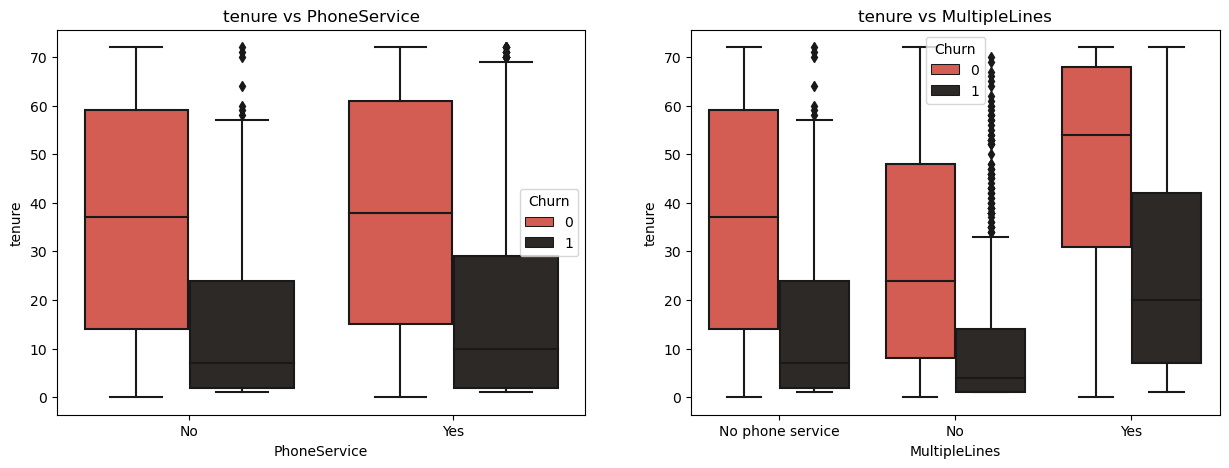

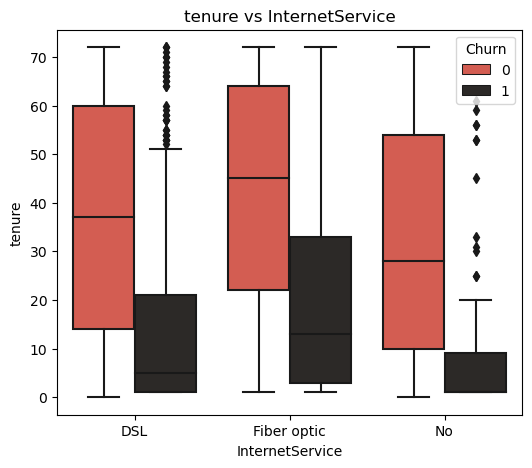

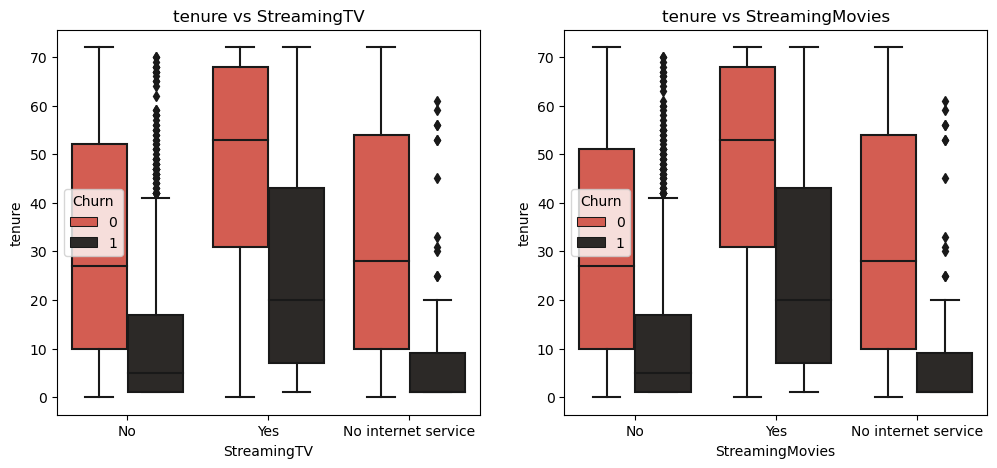

In [34]:
fig = plt.subplots(nrows = 1,ncols = 2,figsize = (15,5))

for i in range(len(l2[0:2])):
    plt.subplot(1,2,i + 1)
    ax = sns.boxplot(x = l2[i],y = 'tenure',data = df,hue = 'Churn',palette = colors);
    plt.title('tenure vs ' + l2[i]);

fig = plt.subplots(nrows = 1, ncols = 1, figsize = (6,5))

plt.subplot(1,1,1)
ax = sns.boxplot(x = l2[2],y = 'tenure',data = df,hue = 'Churn',palette = colors);
plt.title('tenure vs ' + l2[2]);
    
fig = plt.subplots(nrows = 1,ncols = 2,figsize = (12,5))

for i in range(len(l2[3:5])):
    plt.subplot(1,2,i + 1)
    ax = sns.boxplot(x = l2[i + 3],y = 'tenure',data = df,hue = 'Churn',palette = colors);
    plt.title('tenure vs ' + l2[i + 3]);

### Comments

The presence of MultipleLines influences the average Monthly Charges regardless of whether customers churned or not.

For the tenure and PhoneService plot, the availability or absence of PhoneService does not change the visuals. Customers were probably not heavy phone (calling–messaging) users.

For InternetService, customers seem quite skeptical about the use of Fiber Optic cables, as confusion lasts for about 30–35 months, after which they either continue without upgrading or switch to a new connection!

Similarly, for StreamingTV and StreamingMovies, a period of approximately 10–40 months of inactivity can be observed!

### tenure vs Group 2: Services Subscribed by the Customer : OnlineSecurity | OnlineBackup | DeviceProtection | TechSupport


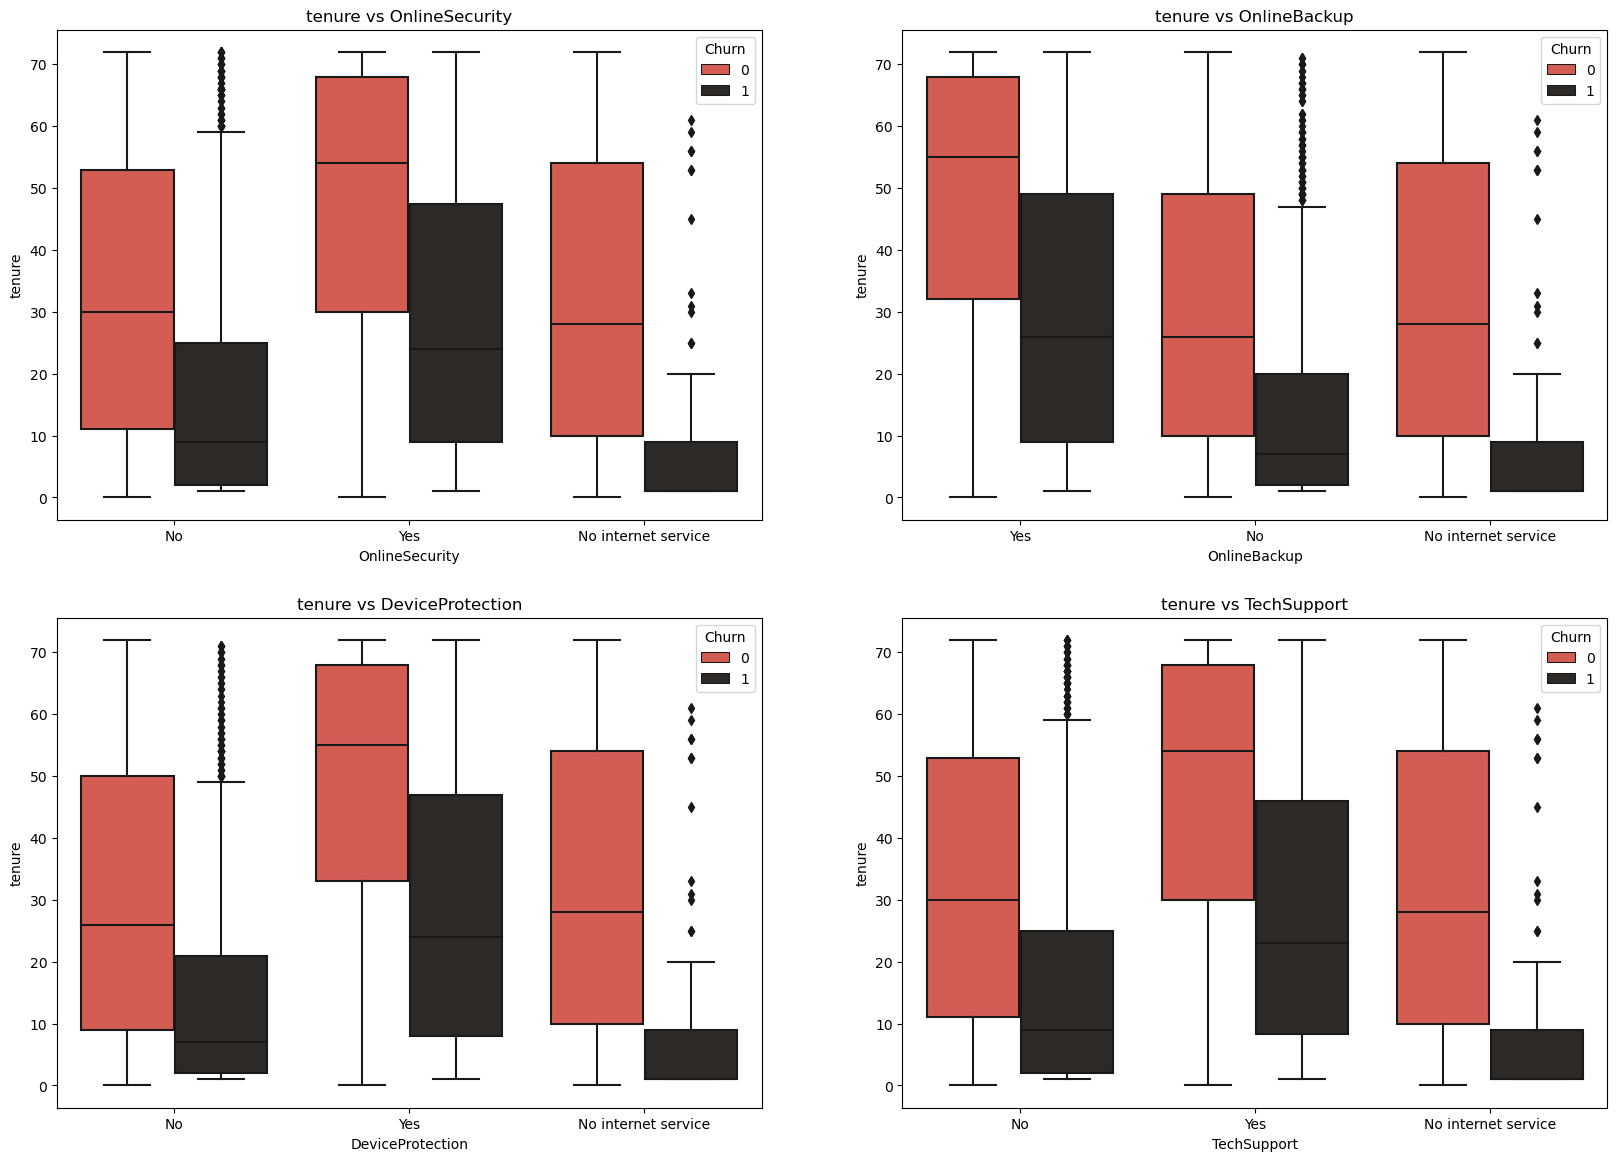

In [35]:
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (20,14))
for i in range(len(l2[-4:])):
    plt.subplot(2,2,i + 1)
    ax = sns.boxplot(x = l2[i - 4],y = 'tenure',data = df,hue = 'Churn',palette = colors);
    plt.title('tenure vs ' + l2[i-4]);

### Comments

For OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport, the average churn tenure value is 25 months. The highest value of this churn tenure is approximately 45 months.

The 30–35 month period is the time when customers make a decision—whether they will continue with their current services or switch to the features mentioned above!

## tenure vs Group 3 : Contract | PaperlessBilling | PaymentMethod |¶


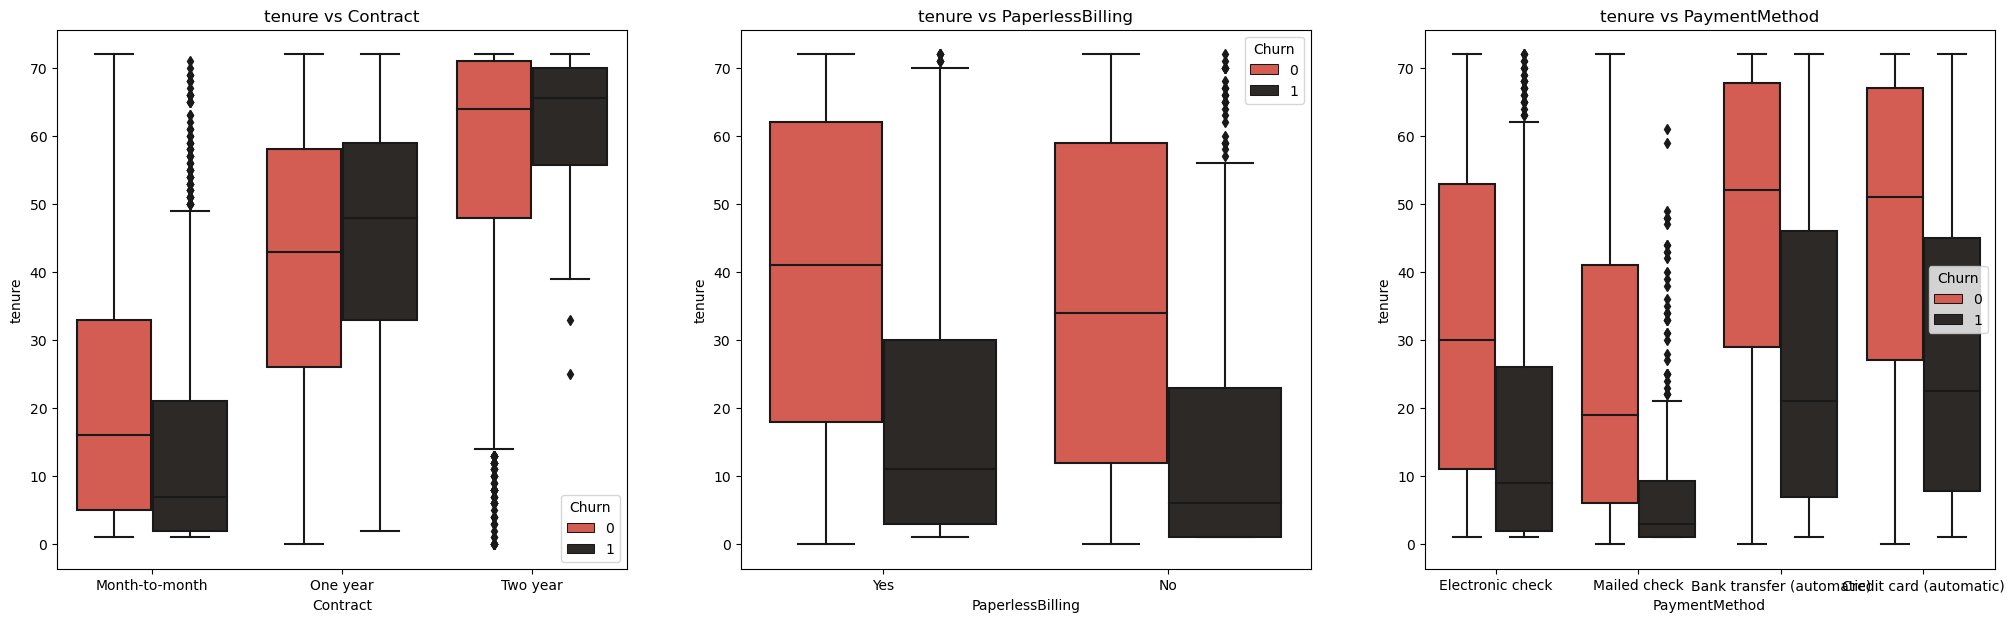

In [36]:
fig = plt.subplots(nrows = 1,ncols = 3,figsize = (25,7))
for i in range(len(l3)):
    plt.subplot(1,3,i + 1)
    ax = sns.boxplot(x = l3[i],y = 'tenure',data = df,hue = 'Churn',palette = colors);
    plt.title('tenure vs ' + l3[i]);

Comments

When customers sign One-Year and Two-Year contracts, they seem to continue using the services for approximately 25 months and 45 months, respectively! However, they start questioning the services and consider switching after crossing the 35-month and 55-month marks, respectively!

Regardless of Paperless Billing, customers start considering switching from the 1st month onward.

In terms of Payment Method, the average churn tenure for Bank Transfer (automatic) and Credit Card (automatic) is above 20 months, which is almost twice that of Electronic Check and Mailed Check (approximately 10 months and about 5 months, respectively).

## MonthlyCharges vs Group 1 : Customer Information : gender | SeniorCitizen | Partner | Dependents


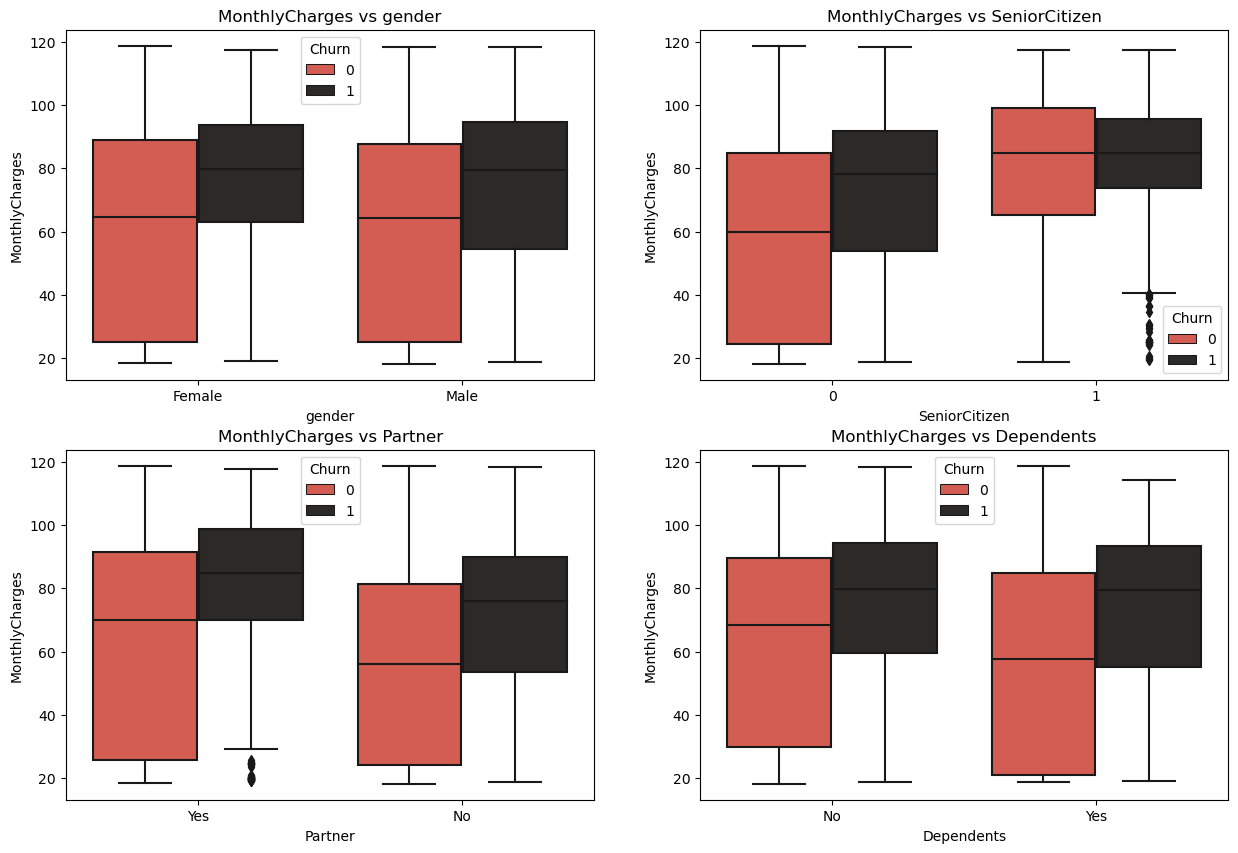

In [37]:
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (15,10))
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = l1[i],y = 'MonthlyCharges',data = df,hue = 'Churn',palette = colors); 
    plt.title('MonthlyCharges vs ' + l1[i]);

Comments

For all the features mentioned above, the median value of customers who did not churn is very close to the lower bound of the customers who did not churn.

The average Monthly Charges for male and female customers are around 60. For Senior Citizens, this value increases to 80.

Customers living with a partner have a higher lower churn limit (MonthlyCharges) of 70, compared to those living alone; for customers living alone, the MonthlyCharges value is slightly below 60!

### MonthlyCharges vs Group 2: Services Subscribed by the Customer : PhoneService | MultipleLines | InternetService | StreamingTV | StreamingMovies


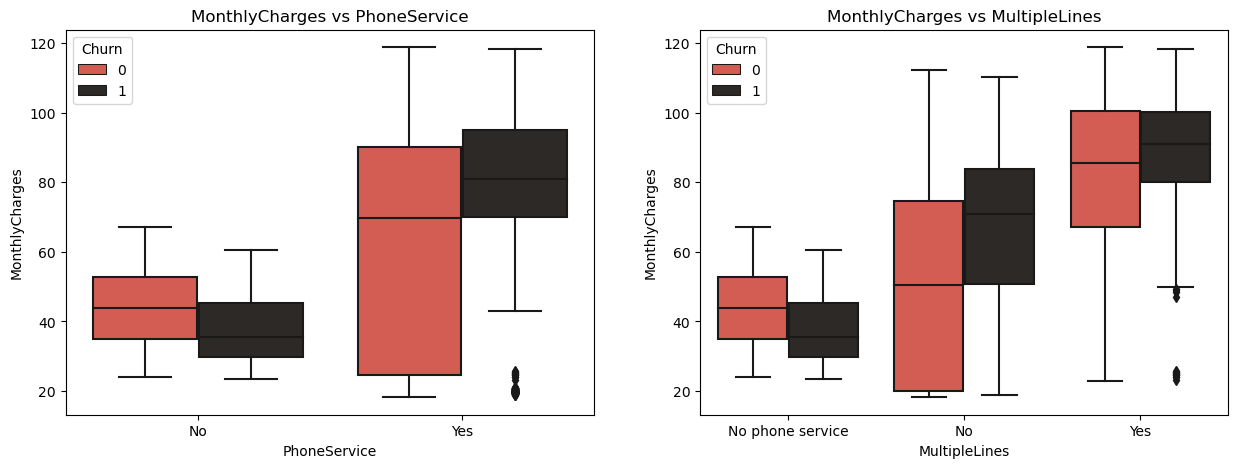

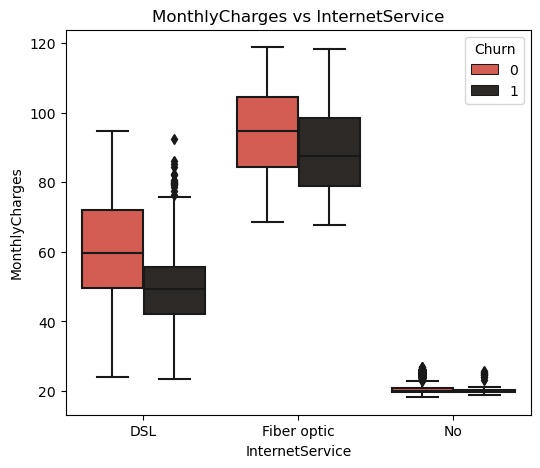

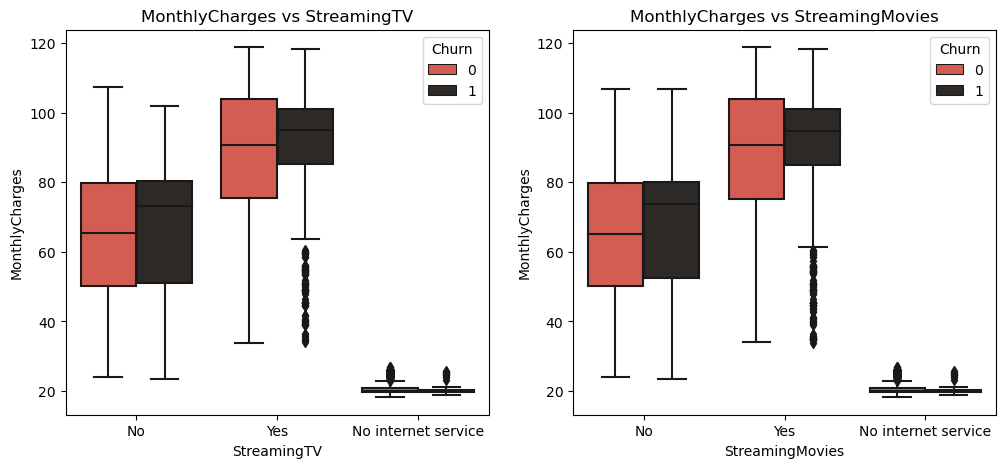

In [38]:
fig = plt.subplots(nrows = 1,ncols = 2,figsize = (15,5))

for i in range(len(l2[0:2])):
    plt.subplot(1,2,i + 1)
    ax = sns.boxplot(x = l2[i],y = 'MonthlyCharges',data = df,hue = 'Churn',palette = colors);
    plt.title('MonthlyCharges vs ' + l2[i]);

fig = plt.subplots(nrows = 1, ncols = 1, figsize = (6,5))

plt.subplot(1,1,1)
ax = sns.boxplot(x = l2[2],y = 'MonthlyCharges',data = df,hue = 'Churn',palette = colors);
plt.title('MonthlyCharges vs ' + l2[2]);
    
fig = plt.subplots(nrows = 1,ncols = 2,figsize = (12,5))

for i in range(len(l2[3:5])):
    plt.subplot(1,2,i + 1)
    ax = sns.boxplot(x = l2[i + 3],y = 'MonthlyCharges',data = df,hue = 'Churn',palette = colors);
    plt.title('MonthlyCharges vs ' + l2[i + 3]);

Comments

The Monthly Charges for Fiber Optic cables are very high. This may be the reason for such a high churn rate.

Similarly, the Monthly Charges for StreamingTV and StreamingMovies are also quite high.

For PhoneService, the Monthly Charges range between 25 and 85, but customers start considering cancellation once MonthlyCharges reach a value of 75.

## MonthlyCharges vs Group 2: Services Subscribed by the Customer : OnlineSecurity | OnlineBackup | DeviceProtection | TechSupport

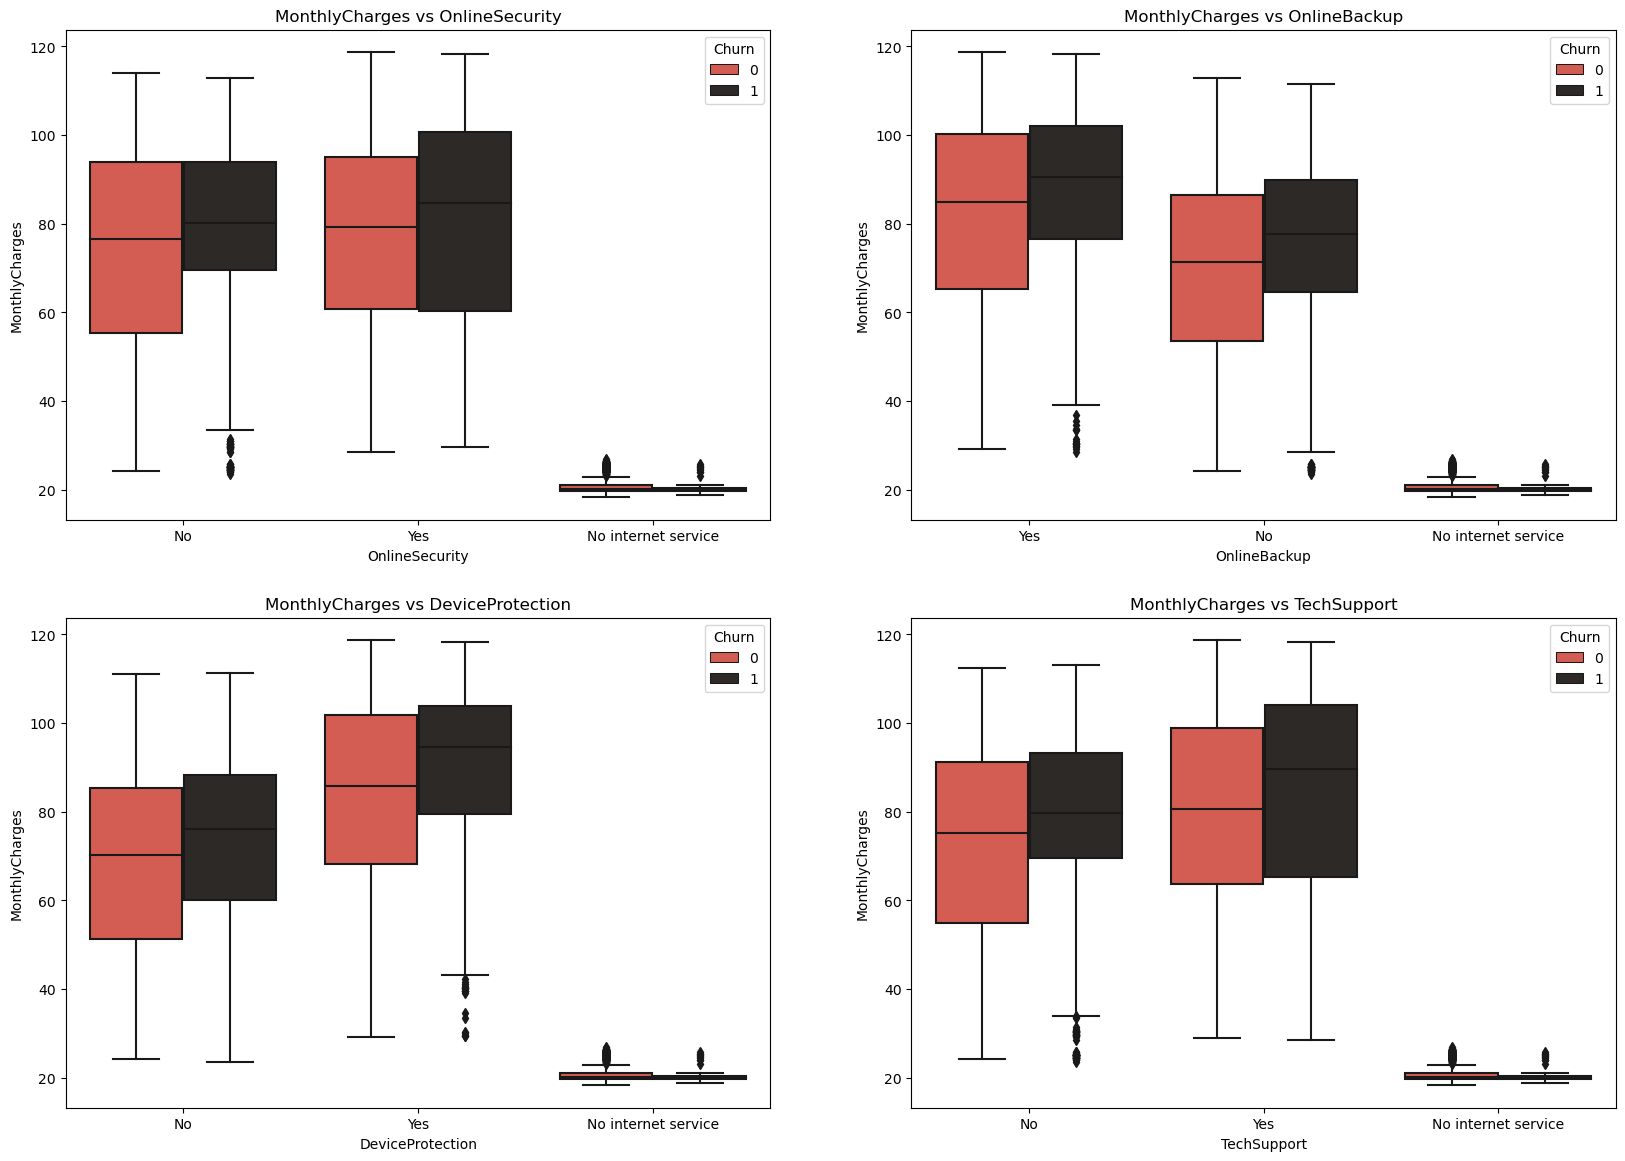

In [39]:
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (20,14))
for i in range(len(l2[-4:])):
    plt.subplot(2,2,i + 1)
    ax = sns.boxplot(x = l2[i - 4],y = 'MonthlyCharges',data = df,hue = 'Churn',palette = colors);
    plt.title('MonthlyCharges vs ' + l2[i-4]);

Comments

The value range for OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport is approximately 50 to 100.

Customers who subscribe to these services are likely not considering cancelling due to MonthlyCharges, because the value range for customers who churned and those who continued is almost the same!

### MonthlyCharges vs Group 3 : Contract | PaperlessBilling | PaymentMethod 

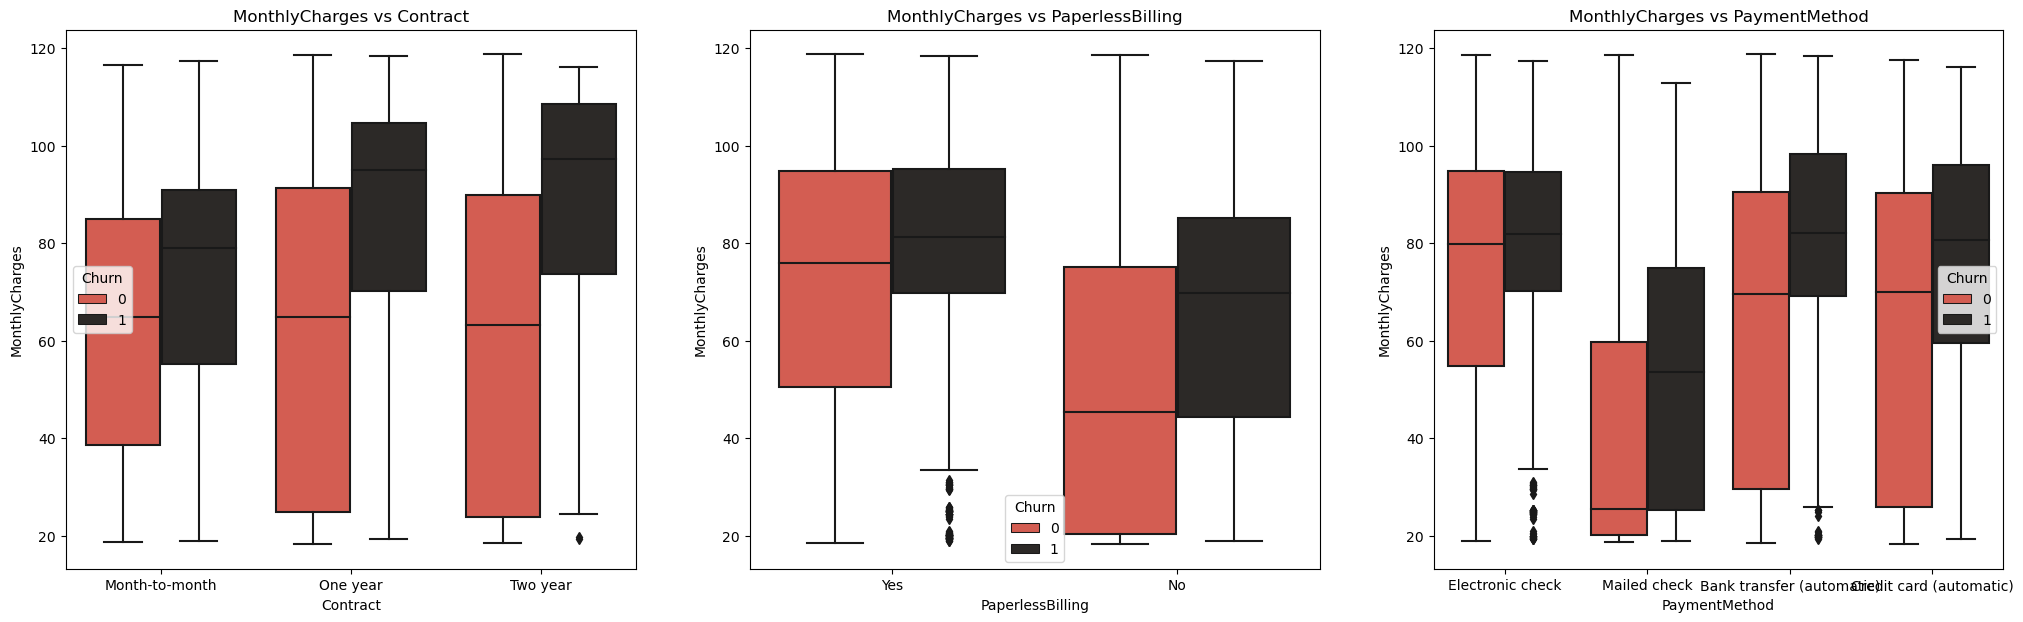

In [40]:
fig = plt.subplots(nrows = 1,ncols = 3,figsize = (25,7))

for i in range(len(l3)):
    plt.subplot(1,3,i + 1)
    ax = sns.boxplot(x = l3[i],y = 'MonthlyCharges',data = df,hue = 'Churn',palette = colors);
    title = 'MonthlyCharges vs ' + l3[i]
    plt.title(title);

### Comments

The lower limit of Monthly Charges for Month-to-Month contracts is higher than that of One-Year and Two-Year contracts. However, for Month-to-Month contracts, the lower limit for customers who churned is lower.

The lower limit of Electronic Check is very high, and this could be a major factor causing customers to stop using it!

Mailed Check has the lowest starting values for both customers who churned and those who continued.

## TotalCharges vs Group 1 : Customer Information : gender | SeniorCitizen | Partner | Dependents 

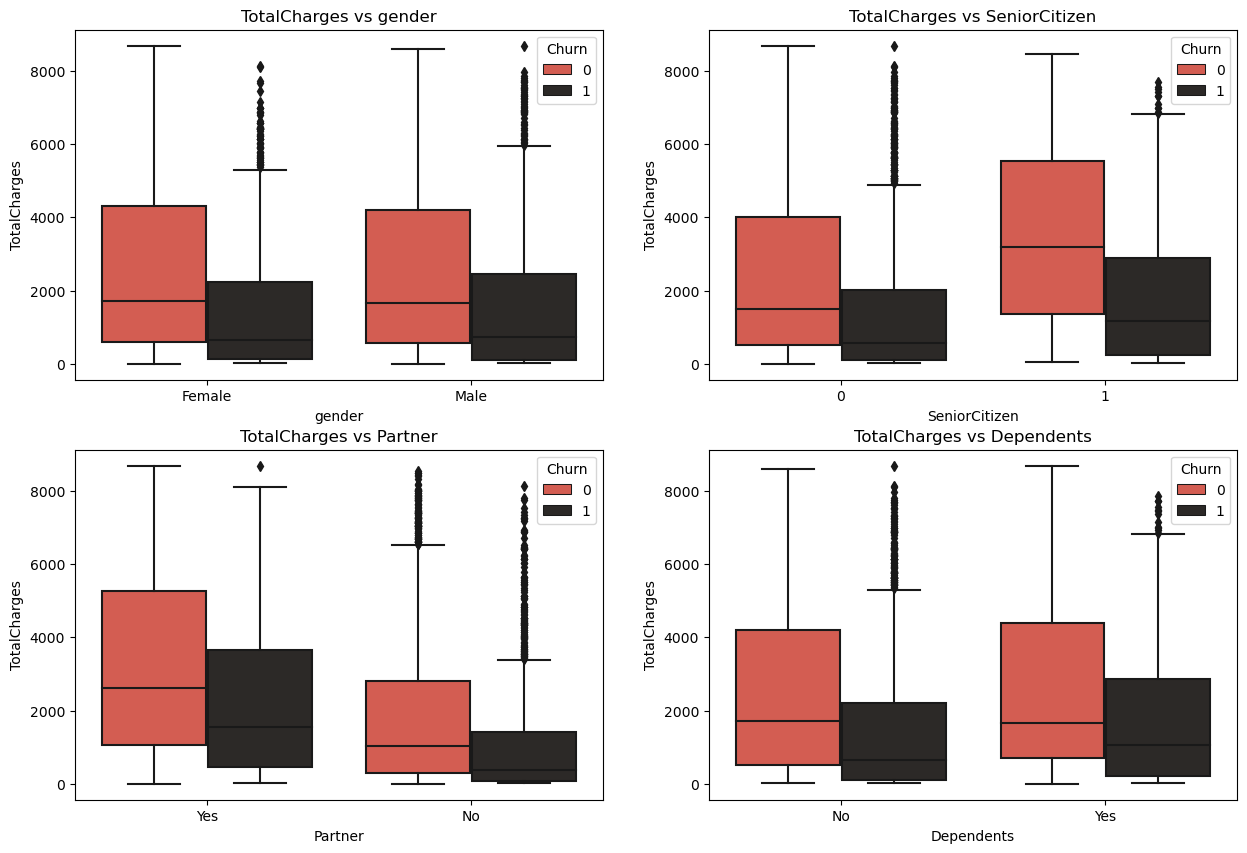

In [41]:
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (15,10))
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = l1[i],y = 'TotalCharges',data = df,hue = 'Churn',palette = colors);
    plt.title('TotalCharges vs ' + l1[i]);

### Comments

The TotalCharges for male and female customers are exactly the same! The starting and ending values of TotalCharges are higher for Senior Citizens who continue using the service.

The average TotalCharges of customers living with a partner is higher compared to those living alone!

## TotalCharges vs Group 2: Services Subscribed by the Customer : PhoneService | MultipleLines | InternetService | StreamingTV | StreamingMovies 


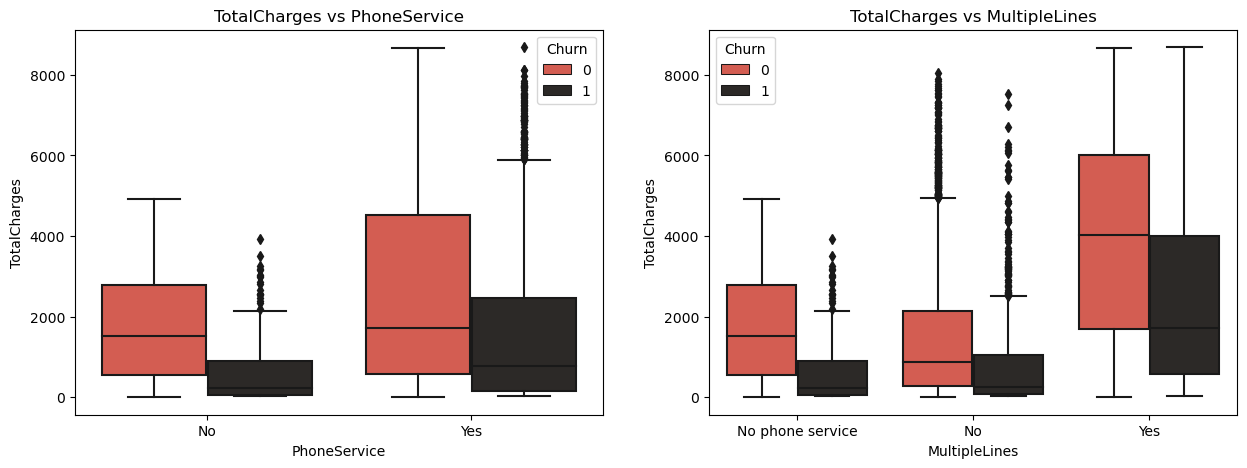

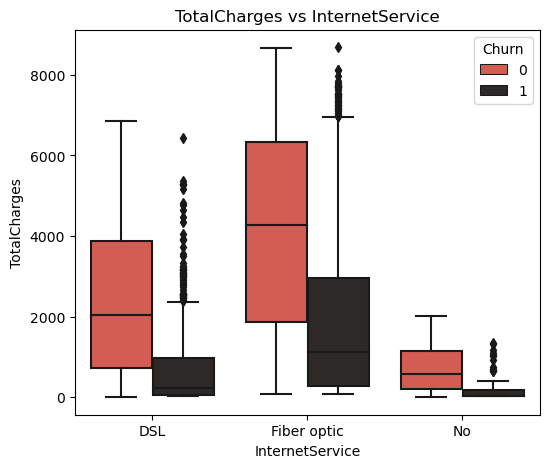

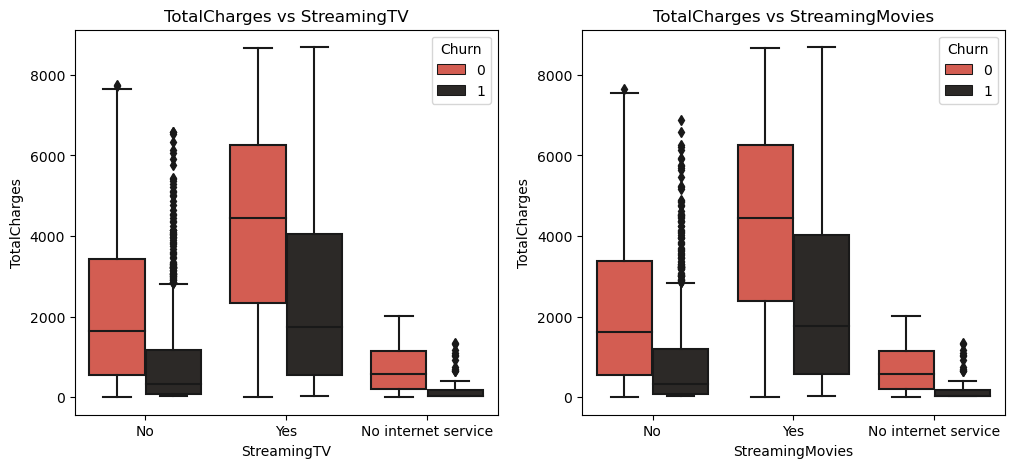

In [42]:
fig = plt.subplots(nrows = 1,ncols = 2,figsize = (15,5))

for i in range(len(l2[0:2])):
    plt.subplot(1,2,i + 1)
    ax = sns.boxplot(x = l2[i],y = 'TotalCharges',data = df,hue = 'Churn',palette = colors);
    plt.title('TotalCharges vs ' + l2[i]);

fig = plt.subplots(nrows = 1, ncols = 1, figsize = (6,5))

plt.subplot(1,1,1)
ax = sns.boxplot(x = l2[2],y = 'TotalCharges',data = df,hue = 'Churn',palette = colors);
plt.title('TotalCharges vs ' + l2[2]);
    
fig = plt.subplots(nrows = 1,ncols = 2,figsize = (12,5))

for i in range(len(l2[3:5])):
    plt.subplot(1,2,i + 1)
    ax = sns.boxplot(x = l2[i + 3],y = 'TotalCharges',data = df,hue = 'Churn',palette = colors);
    plt.title('TotalCharges vs ' + l2[i + 3]);

### Comments

The TotalCharges for Phone Service range between 0 and 4000. However, customers start having second thoughts about the Phone Service once TotalCharges reach around 1000.

Similarly, customers begin hesitating to pay for MultipleLines once the amount reaches around 2000. However, some customers seem desperate, as they have paid values around 6000 for MultipleLines!

As for Fiber Optic cable payments, customers test the products by paying around 2000!

Similar to Fiber Optic, customers who continue using StreamingTV and StreamingMovies pay between 3000 and 6000 for these services.

## TotalCharges vs Group 2: Services Subscribed by the Customer : OnlineSecurity | OnlineBackup | DeviceProtection | TechSupport |


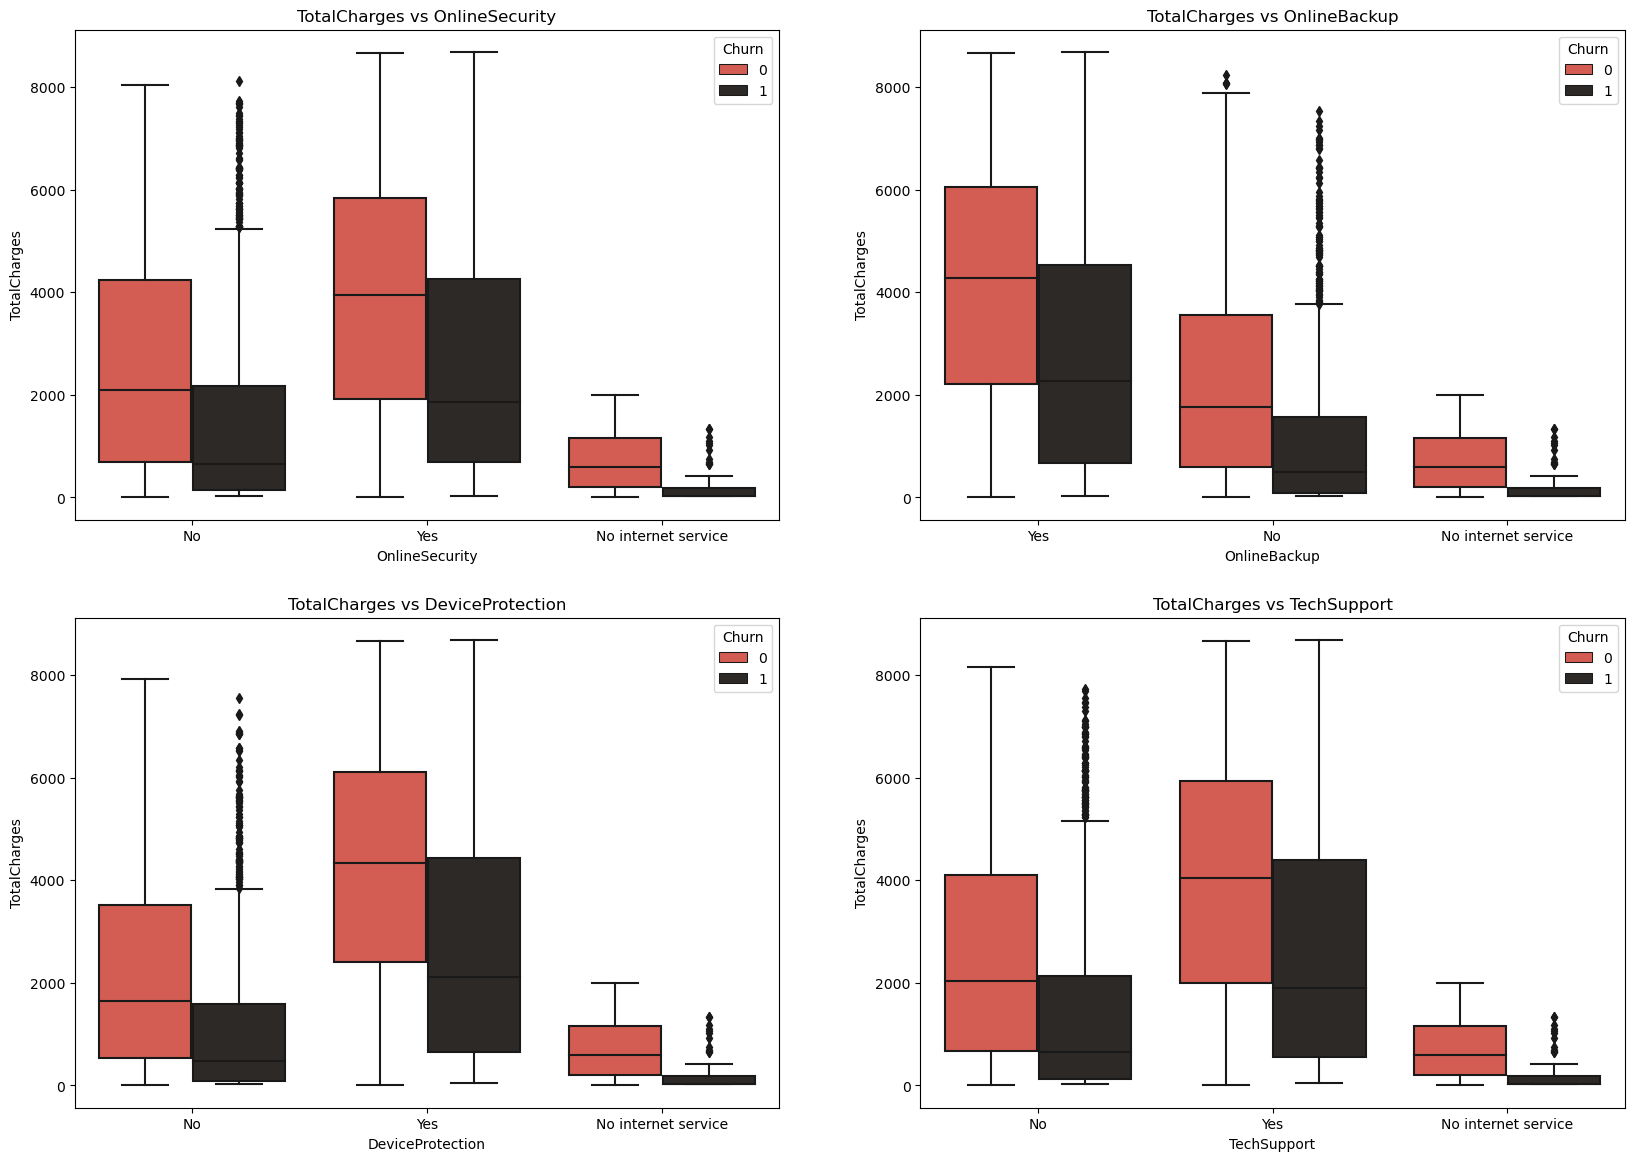

In [ ]:
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (20,14))
for i in range(len(l2[-4:])):
    plt.subplot(2,2,i + 1)
    ax = sns.boxplot(x = l2[i - 4],y = 'TotalCharges',data = df,hue = 'Churn',palette = colors)
    plt.title('TotalCharges vs ' + l2[i-4])

For all the features mentioned above, customers start becoming skeptical about paying for them at around 2000. The median value for customers who churned is very close to the lower bound of customers who continued using these services.

Customers who do not cancel their subscriptions are willing to pay between 2000 and 6000 in TotalCharges.

## TotalCharges vs Group 3 : Contract | PaperlessBilling | PaymentMethod |¶


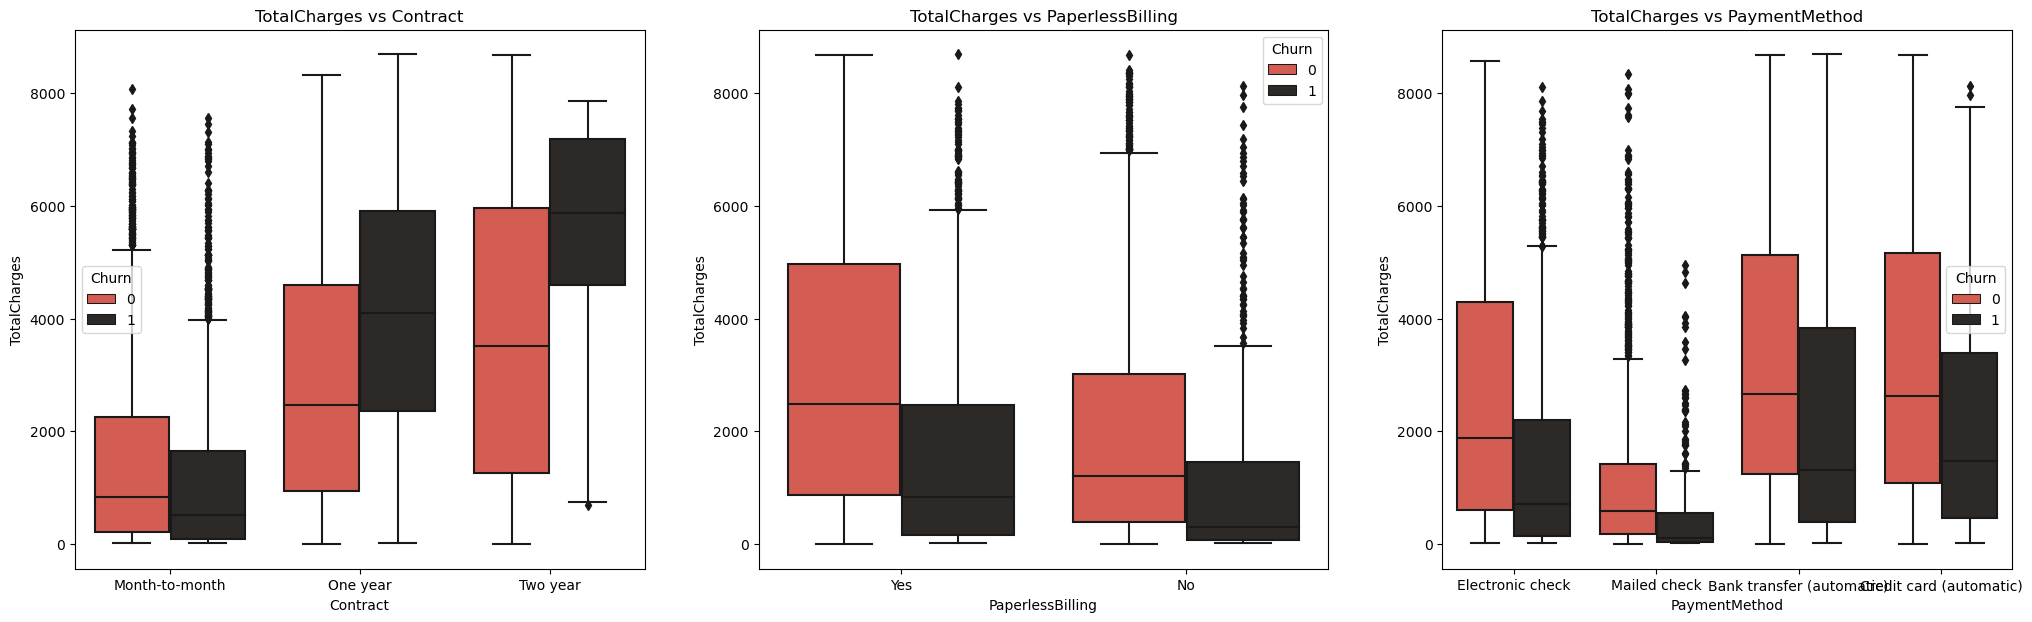

In [ ]:
fig = plt.subplots(nrows = 1,ncols = 3,figsize = (25,7))

for i in range(len(l3)):
    plt.subplot(1,3,i + 1)
    ax = sns.boxplot(x = l3[i],y = 'TotalCharges',data = df,hue = 'Churn',palette = colors)
    plt.title('TotalCharges vs ' + l3[i]);

### Comments

The average TotalCharges values for customers who decided to discontinue One-Year and Two-Year contract services are high, around 4000 and 6000. Some customers with two-year contracts even paid around 7000.

For PaymentMethod, customers are skeptical about paying 0–2000 using Electronic Check, whereas for Bank Transfer (automatic) and Credit Card (automatic), this range extends to around 0–4000.

## Numerical features vs Numerical features w.r.t Target variable (Churn) :


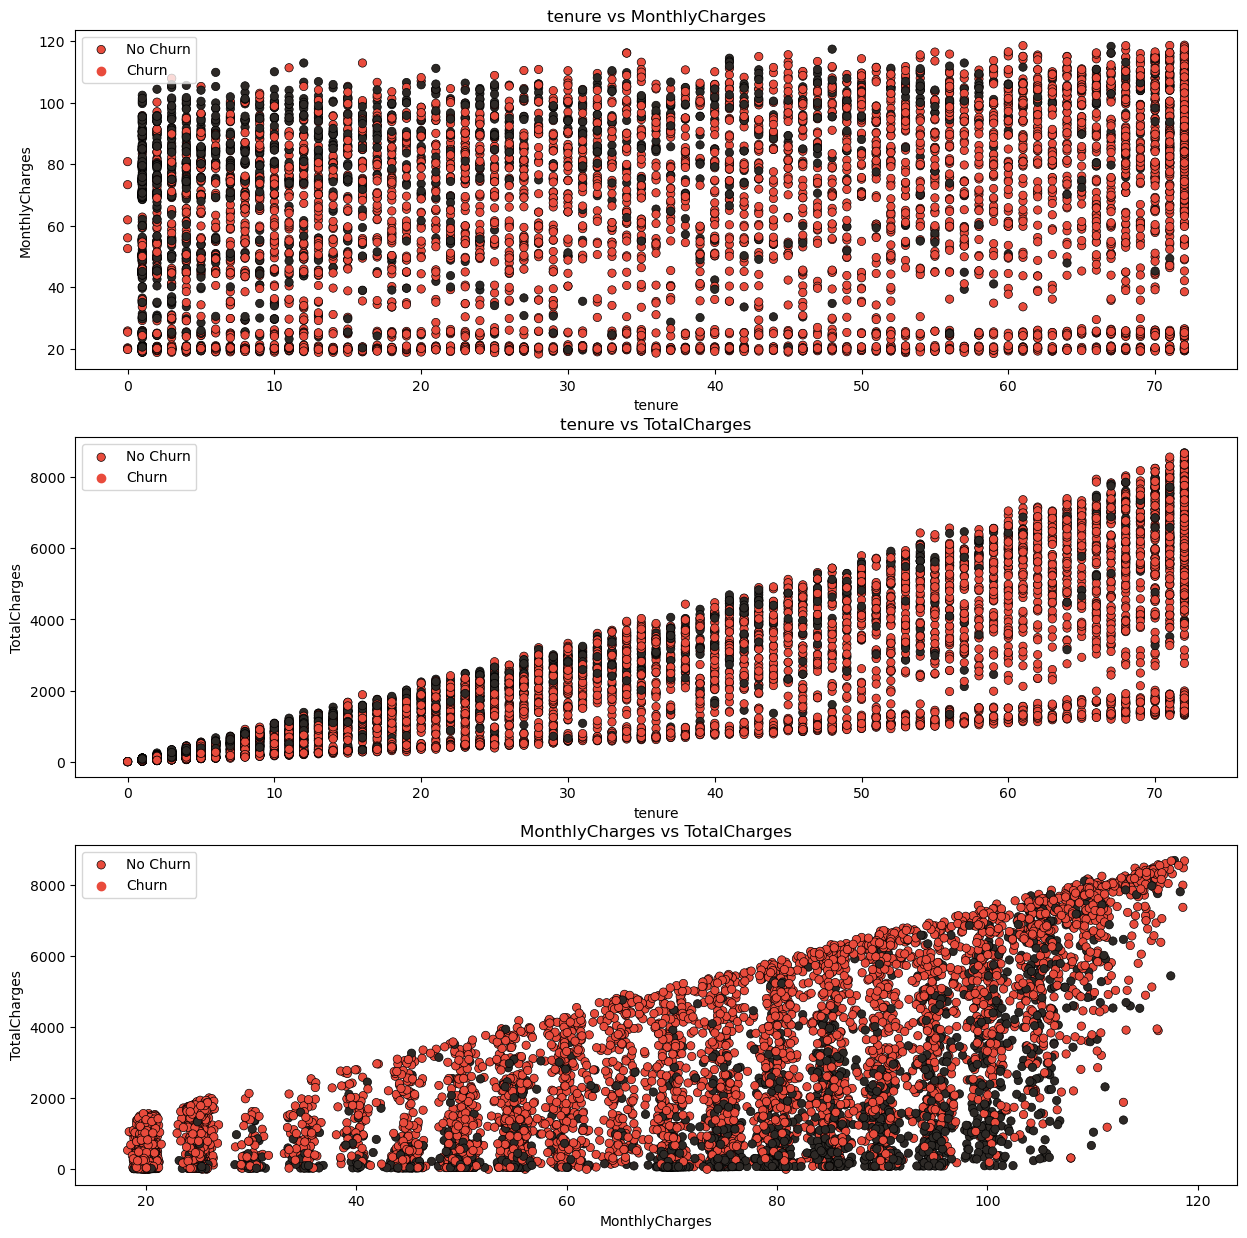

In [45]:
a = 0
fig,ax = plt.subplots(nrows = 3,ncols = 1,figsize = (15,15))
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        if i != j and j > i:
            a += 1
            plt.subplot(3,1,a)
            sns.scatterplot(x = num_cols[i],y = num_cols[j],data = df,hue = 'Churn',palette = colors,edgecolor = 'black');
            plt.legend(['No Churn','Churn'],loc = 'upper left',)
            title = num_cols[i] + ' vs ' + num_cols[j]
            plt.title(title)

### Comments

For a tenure of 0–20 months, customers fluctuate quite a lot at any MonthlyCharges value.

During a tenure of 20–60 months, customers whose MonthlyCharges values are at the upper limit (70–120) begin to leave the services.

For TotalCharges and tenure, as tenure increases, TotalCharges also increases! Customers who leave their plans are those who have been charged the highest amounts during their tenure, along with a few customers whose TotalCharges are in the middle range.

When MonthlyCharges reach 70 or above, customers seem to decide to cancel their subscriptions.

# Feature Engineering

In [46]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
mms = MinMaxScaler() # Normalization
ss = StandardScaler() # Standardization

df.drop(columns = ['MonthlyCharges_Group','TotalCharges_Group'], inplace = True)

df['tenure'] = mms.fit_transform(df[['tenure']])
df['MonthlyCharges'] = mms.fit_transform(df[['MonthlyCharges']])
df['TotalCharges'] = mms.fit_transform(df[['TotalCharges']])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,0.013889,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,0.115423,0.003437,0
1,Male,0,No,No,0.472222,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,0.385075,0.217564,0
2,Male,0,No,No,0.027778,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,0.354229,0.012453,1
3,Male,0,No,No,0.625000,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),0.239303,0.211951,0
4,Female,0,No,No,0.027778,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,0.521891,0.017462,1


### Comments
A machine learning model does not understand the units of the feature values. It treats the input as simple numbers and does not grasp the true meaning behind those values. Therefore, scaling the data becomes necessary.


We have 2 options for data scaling:
1) Normalization
2) Standardization


Since most algorithms assume that the data follows a normal (Gaussian) distribution, normalization is applied to features that do not exhibit a normal distribution, and standardization is applied to features that do follow a normal distribution but have values that are very large or very small compared to other features.


Normalization: Tenure, MonthlyCharges, and TotalCharges were normalized because they show right-skewed and bimodal distributions.


Standardization: None of the features were standardized for the above data.




### Correlation Matrix

C:\Users\gurkanc\AppData\Local\Temp\ipykernel_27168\1157013609.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap=colors, annot=True);


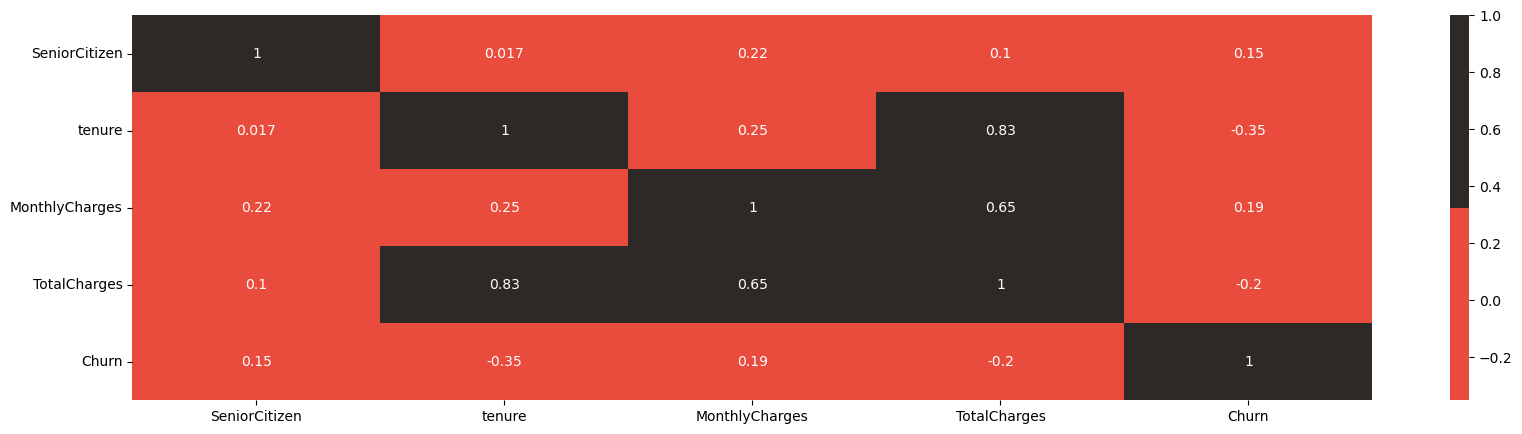

In [ ]:
plt.figure(figsize = (20,5))
sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap=colors, annot=True)

C:\Users\gurkanc\AppData\Local\Temp\ipykernel_27168\120723030.py:1: FutureWarning: The default value of numeric_only in DataFrame.corrwith is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df.corrwith(df['Churn']).sort_values(ascending = False).to_frame()


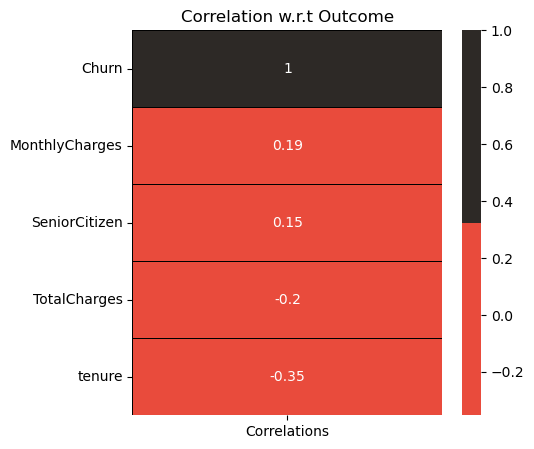

In [ ]:
corr = df.corrwith(df['Churn']).sort_values(ascending = False).to_frame()
corr.columns = ['Correlations']
plt.subplots(figsize = (5,5))
sns.heatmap(corr,annot = True,cmap = colors,linewidths = 0.4,linecolor = 'black')
plt.title('Correlation w.r.t Outcome')

### Feature Selection 

In [49]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df = df.copy(deep = True)
# Robustly select all object (string) columns
text_data_features = df.select_dtypes(include=['object']).columns

print('Label Encoder Transformation')
for i in text_data_features :
    df[i] = le.fit_transform(df[i])
    print(i,' : ',df[i].unique(),' = ',le.inverse_transform(df[i].unique()))

Label Encoder Transformation
gender  :  [0 1]  =  ['Female' 'Male']
Partner  :  [1 0]  =  ['Yes' 'No']
Dependents  :  [0 1]  =  ['No' 'Yes']
PhoneService  :  [0 1]  =  ['No' 'Yes']
MultipleLines  :  [1 0 2]  =  ['No phone service' 'No' 'Yes']
InternetService  :  [0 1 2]  =  ['DSL' 'Fiber optic' 'No']
OnlineSecurity  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
OnlineBackup  :  [2 0 1]  =  ['Yes' 'No' 'No internet service']
DeviceProtection  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
TechSupport  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
StreamingTV  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
StreamingMovies  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
Contract  :  [0 1 2]  =  ['Month-to-month' 'One year' 'Two year']
PaperlessBilling  :  [1 0]  =  ['Yes' 'No']
PaymentMethod  :  [2 3 0 1]  =  ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [50]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,0.013889,0,1,0,0,2,0,0,0,0,0,1,2,0.115423,0.003437,0
1,1,0,0,0,0.472222,1,0,0,2,0,2,0,0,0,1,0,3,0.385075,0.217564,0
2,1,0,0,0,0.027778,1,0,0,2,2,0,0,0,0,0,1,3,0.354229,0.012453,1
3,1,0,0,0,0.625000,0,1,0,2,0,2,2,0,0,1,0,0,0.239303,0.211951,0
4,0,0,0,0,0.027778,1,0,1,0,0,0,0,0,0,0,1,2,0.521891,0.017462,1


In [51]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2,mutual_info_classif

In [52]:
df.loc[:,cat_cols]

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,SeniorCitizen
0,0,1,0,0,1,0,0,2,0,0,0,0,0,1,2,0,0
1,1,0,0,1,0,0,2,0,2,0,0,0,1,0,3,0,0
2,1,0,0,1,0,0,2,2,0,0,0,0,0,1,3,1,0
3,1,0,0,0,1,0,2,0,2,2,0,0,1,0,0,0,0
4,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,1,1,1,2,0,2,0,2,2,2,2,1,1,3,0,0
7039,0,1,1,1,2,1,0,2,2,0,2,2,1,1,1,0,0
7040,0,1,1,0,1,0,2,0,0,0,0,0,0,1,2,0,0
7041,1,1,0,1,2,1,0,0,0,0,0,0,0,1,3,1,1


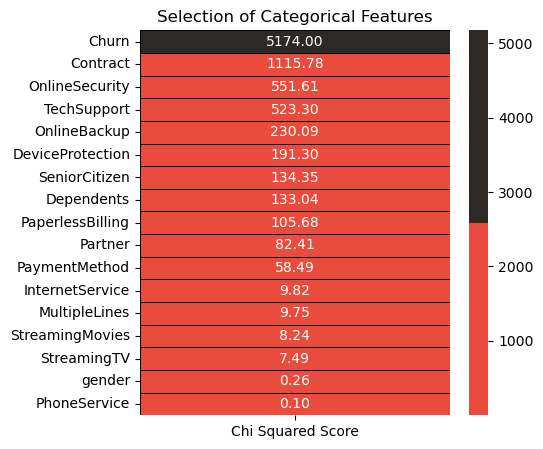

In [ ]:
features = df.loc[:,cat_cols]
target = df.loc[:,'Churn']

best_features = SelectKBest(score_func = chi2,k = 'all')
fit = best_features.fit(features,target)

featureScores = pd.DataFrame(data = fit.scores_,index = list(features.columns),columns = ['Chi Squared Score']) 

plt.subplots(figsize = (5,5))
sns.heatmap(featureScores.sort_values(ascending = False,by = 'Chi Squared Score'),annot = True,cmap = colors,linewidths = 0.4,linecolor = 'black',fmt = '.2f')
plt.title('Selection of Categorical Features')

* PhoneService, gender, StreamingTV, StreamingMovies, MultipleLines, and InternetService show a very low relationship with Churn.

### Feature Selection for Numerical Features :¶


In [54]:
from sklearn.feature_selection import f_classif

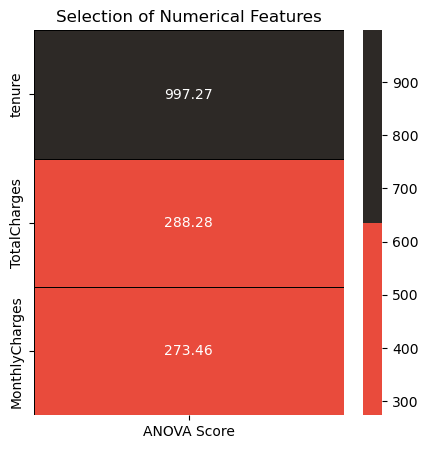

In [ ]:
features = df.loc[:,num_cols]
target = df.loc[:,'Churn']

best_features = SelectKBest(score_func = f_classif,k = 'all')
fit = best_features.fit(features,target)

featureScores = pd.DataFrame(data = fit.scores_,index = list(features.columns),columns = ['ANOVA Score']) 

plt.subplots(figsize = (5,5))
sns.heatmap(featureScores.sort_values(ascending = False,by = 'ANOVA Score'),annot = True,cmap = colors,linewidths = 0.4,linecolor = 'black',fmt = '.2f');
plt.title('Selection of Numerical Features')

Comments

According to the ANOVA test, the higher the ANOVA score, the more important the feature is.

From the results above, we need to include all numerical features for modeling.

In [56]:
df.drop(columns = ['PhoneService', 'gender','StreamingTV','StreamingMovies','MultipleLines','InternetService'],inplace = True)
df.head()

,SeniorCitizen,Partner,Dependents,tenure,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,0,0.013889,0,2,0,0,0,1,2,0.115423,0.003437,0
1,0,0,0,0.472222,2,0,2,0,1,0,3,0.385075,0.217564,0
2,0,0,0,0.027778,2,2,0,0,0,1,3,0.354229,0.012453,1
3,0,0,0,0.625000,2,0,2,2,1,0,0,0.239303,0.211951,0
4,0,0,0,0.027778,0,0,0,0,0,1,2,0.521891,0.017462,1


### Balancing

There are 2 options for dealing with imbalanced data:

* Undersampling: Trim the majority samples of the target variable.

* Oversampling: Increase the minority samples of the target variable to match the majority samples.

* After trial and error with undersampling and oversampling, we decided to use oversampling!

We will use imblearn for data balancing.
pip statement: pip install imbalanced-learn

In [57]:
import imblearn
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

In [58]:
over = SMOTE(sampling_strategy = 1)

f1 = df.iloc[:,:13].values
t1 = df.iloc[:,13].values

f1, t1 = over.fit_resample(f1, t1)
Counter(t1)

Counter({0: 5174, 1: 5174})

# MODELING

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import precision_recall_curve

In [60]:
x_train, x_test, y_train, y_test = train_test_split(f1, t1, test_size = 0.20, random_state = 2)

In [61]:
def model(classifier,x_train,y_train,x_test,y_test):
    
    classifier.fit(x_train,y_train)
    prediction = classifier.predict(x_test)
    cv = RepeatedStratifiedKFold(n_splits = 10,n_repeats = 3,random_state = 1)
    print("Cross Validation Score : ",'{0:.2%}'.format(cross_val_score(classifier,x_train,y_train,cv = cv,scoring = 'roc_auc').mean()))
    print("ROC_AUC Score : ",'{0:.2%}'.format(roc_auc_score(y_test,prediction)))
    plt.show()

def model_evaluation(classifier,x_test,y_test):
    
    # Confusion Matrix
    cm = confusion_matrix(y_test,classifier.predict(x_test))
    names = ['True Neg','False Pos','False Neg','True Pos']
    counts = [value for value in cm.flatten()]
    percentages = ['{0:.2%}'.format(value) for value in cm.flatten()/np.sum(cm)]
    labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in zip(names,counts,percentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(cm,annot = labels,cmap = 'Blues',fmt ='')
    
    # Classification Report
    print(classification_report(y_test,classifier.predict(x_test)))

### 1-) XGB Classifier

In [62]:
from xgboost import XGBClassifier

classifier_xgb = XGBClassifier(learning_rate= 0.01,max_depth = 3,n_estimators = 1000)

In [63]:
model(classifier_xgb,x_train,y_train,x_test,y_test)

Cross Validation Score :  90.14%
ROC_AUC Score :  82.29%


              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1040
           1       0.81      0.87      0.83      1030

    accuracy                           0.83      2070
   macro avg       0.83      0.83      0.83      2070
weighted avg       0.83      0.83      0.83      2070



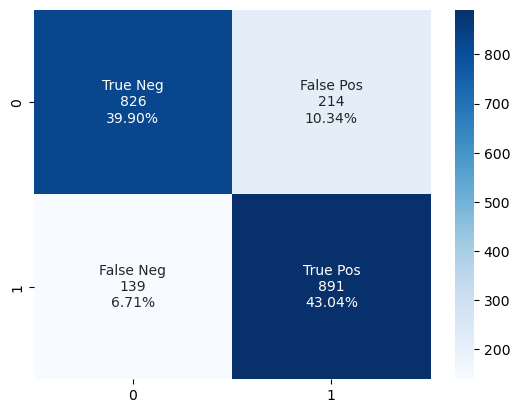

In [64]:
model_evaluation(classifier_xgb,x_test,y_test)

### 2) LGBM Classifier

In [74]:
from lightgbm import LGBMClassifier

classifier_lgbm = LGBMClassifier(learning_rate= 0.01,max_depth = 3,n_estimators = 1000, force_col_wise='true',verbose=-1)

In [75]:
model(classifier_lgbm,x_train,y_train,x_test,y_test)


Cross Validation Score :  90.27%
ROC_AUC Score :  83.01%


              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1040
           1       0.81      0.87      0.83      1030

    accuracy                           0.83      2070
   macro avg       0.83      0.83      0.83      2070
weighted avg       0.83      0.83      0.83      2070



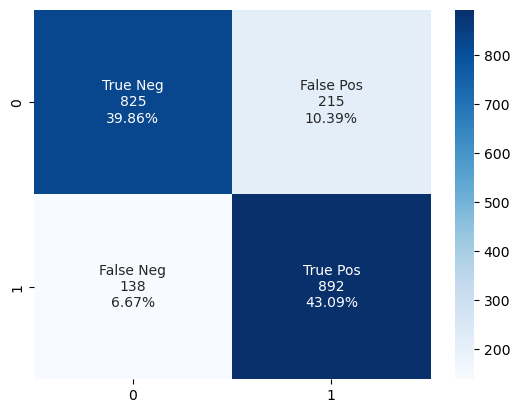

In [67]:
model_evaluation(classifier_lgbm,x_test,y_test)

## Random Forest Classifier

In [68]:
from sklearn.ensemble import RandomForestClassifier
classifier_rf = RandomForestClassifier(max_depth = 4,random_state = 0)


In [69]:
model(classifier_rf,x_train,y_train,x_test,y_test)


Cross Validation Score :  85.80%
ROC_AUC Score :  77.85%


              precision    recall  f1-score   support

           0       0.81      0.72      0.77      1040
           1       0.75      0.83      0.79      1030

    accuracy                           0.78      2070
   macro avg       0.78      0.78      0.78      2070
weighted avg       0.78      0.78      0.78      2070



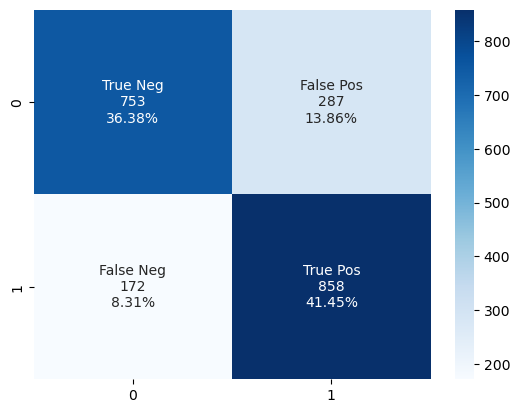

In [70]:
model_evaluation(classifier_rf,x_test,y_test)


# Decision Tree Classifier

In [71]:
from sklearn.tree import DecisionTreeClassifier
classifier_dt = DecisionTreeClassifier(random_state = 1000,max_depth = 4,min_samples_leaf = 1)


In [72]:
model(classifier_dt,x_train,y_train,x_test,y_test)


Cross Validation Score :  84.64%
ROC_AUC Score :  76.62%


              precision    recall  f1-score   support

           0       0.77      0.76      0.77      1040
           1       0.76      0.77      0.77      1030

    accuracy                           0.77      2070
   macro avg       0.77      0.77      0.77      2070
weighted avg       0.77      0.77      0.77      2070



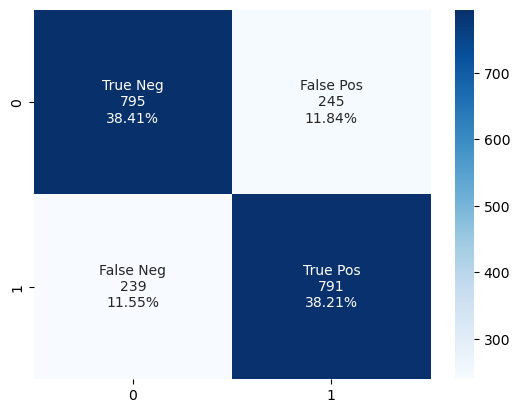

In [73]:
model_evaluation(classifier_dt,x_test,y_test)

## 5) Stack of XGBClassifier, LightGBMClassifier, Random Forest Classifer & Decision Tree Classifier


In [74]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(estimators = [('classifier_xgb',classifier_xgb),
                                         ('classifier_lgbm',classifier_lgbm),
                                         ('classifier_rf',classifier_rf),
                                         ('classifier_dt',classifier_dt)],
                           final_estimator = classifier_lgbm)

For stacking of classifiers, we stack the above 4 classifiers :

* XGBClassifier
* LightGBMClassifier
* RandomForestClassifier
* DecisionTreeClassifier
It has an important hyperparameter known as final_estimator. It is the classifier that makes the final prediction by using the predicted classes by the various classifier and predicts the final output.

In [75]:
model(stack,x_train,y_train,x_test,y_test)

[LightGBM] [Info] Number of positive: 4144, number of negative: 4134
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000747 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1328
[LightGBM] [Info] Number of data points in the train set: 8278, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500604 -> initscore=0.002416
[LightGBM] [Info] Start training from score 0.002416
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1040
           1       0.83      0.85      0.84      1030

    accuracy                           0.84      2070
   macro avg       0.84      0.84      0.84      2070
weighted avg       0.84      0.84      0.84      2070



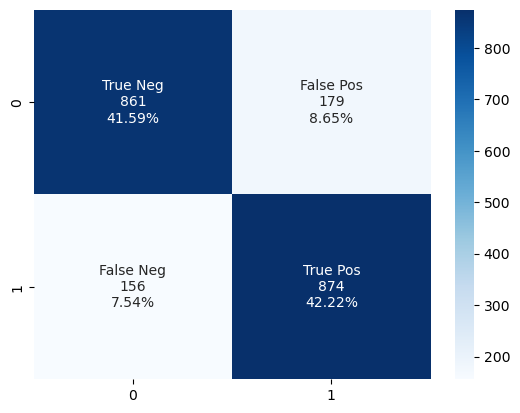

In [76]:
model_evaluation(stack,x_test,y_test)

### Summary

* 3 types of customers should be targeted: Senior Citizens, those living with a partner, and those living alone!

* The number of Senior Citizen customers is small, but their lower limit for Monthly Charges is higher than other customers. Therefore, Senior Citizen customers are willing to pay the highest amount, but they need service quality at that level. Customers with partners and customers living alone prefer services with Monthly Charges below 65.

* During the first 6 months of tenure, which is the most critical and uncertain period for customers, the company needs to focus extensively on OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport. They need to reduce the churn period for these services from 40–50 months.

* After establishing a solid support service pipeline for customers, they need to increase the use of MultipleLines for Phone Service and Fiber Optic cables for Internet Service. However, the biggest barrier for these two services is the MonthlyCharges starting point of 75+.

* Therefore, they need to create option combinations for Phone Service and Internet Service such that the average Monthly Charges fall in the 100–120 range:
-- No MultipleLines + OpticFiber
-- MultipleLines + DSL

* This will eliminate the option of No MultipleLines + DSL, which likely has an average Monthly Charges of 60–70, thus increasing the average revenue per user!

* StreamingTV and StreamingMovies need to be made affordable while also reducing the tenure required for these services. The content of these services should target all types of customers. This must be accompanied by an easy and seamless Payment Method.

* Due to high churn, Electronic Check payments should be phased out, and the focus should shift entirely to Bank Transfer (automatic) and Credit Card (automatic). However, they will need to reduce the average churn tenure for these two payment methods to above 20 months, which is double the tenure for Electronic Check.

* For Monthly Charges, the lower limit for Electronic Check is around 60, whereas the lower limit for Bank Transfer (automatic) and Credit Card (automatic) is around 20. Paperless Billing is another expensive option with a starting point of 60, while other options are cheaper, starting from 20 in Monthly Charges.